# ____________________ FOR GOOGLE COLAB ____________________

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Change the current working directory to the 'master_colab' folder on Google Drive
os.chdir('/content/drive/MyDrive/master_colab')

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/master_colab


# ____________________ FOR GOOGLE COLAB ____________________

In [1]:
import pandas as pd
import numpy as np
import holidays
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LassoCV
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, ParameterSampler
import joblib
import os
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
import gc
from statsmodels.tsa.statespace.sarimax import SARIMAXResults
from statsmodels.tsa.arima.model import ARIMAResults
import os

# Load Data

In [2]:
data = pd.read_parquet("data/ENTSOE/entsoe_price_and_loadfc.parquet")
weather_fc = pd.read_parquet("data/NOAA GFS/weather_forecast.parquet")
data = data.join(weather_fc, how="left")

# Feature Extraction

In [3]:
# lag features (use naive timestamp manipulation to avoid issues with DST transitions)
idx_naive = data.index.tz_localize(None)

prev_naive_day = idx_naive - pd.DateOffset(days=1)
prev_naive_day2 = idx_naive - pd.DateOffset(days=2)
prev_naive_week = idx_naive - pd.DateOffset(weeks=1)

idx_prev_day = prev_naive_day.tz_localize(
    "Europe/Berlin",
    ambiguous=False,
    nonexistent="shift_forward",
)
idx_prev_day2 = prev_naive_day2.tz_localize(
    "Europe/Berlin",
    ambiguous=False,
    nonexistent="shift_forward",
)
idx_prev_week = prev_naive_week.tz_localize(
    "Europe/Berlin",
    ambiguous=False,
    nonexistent="shift_forward",
)


data["price_lag_24h"] = data["da_price"].reindex(idx_prev_day).to_numpy()
data["price_lag_48h"] = data["da_price"].reindex(idx_prev_day2).to_numpy()
data["price_lag_168h"] = data["da_price"].reindex(idx_prev_week).to_numpy()


# weekday in local delivery time
data["weekday_sin"] = np.sin(2 * np.pi * data.index.dayofweek / 7)
data["weekday_cos"] = np.cos(2 * np.pi * data.index.dayofweek / 7)

# hour of local delivery day
data["hour_sin"] = np.sin(2 * np.pi * data.index.hour / 24)
data["hour_cos"] = np.cos(2 * np.pi * data.index.hour / 24)

# holiday not sunday in local delivery time
ger_holidays = list(holidays.Germany(years=data.index.year.unique()))
ger_holidays = pd.to_datetime(ger_holidays).tz_localize(data.index.tz)
data["holiday_not_sunday"] = (data.index.normalize().isin(ger_holidays) & (data.index.dayofweek != 6))

# remove all data outside of local delivery years 2023-2025 (only used for lag features)
data = data["2023":"2025"]

# Splitting

In [4]:
LOCAL_TZ = "Europe/Berlin"

TRAIN_START = pd.Timestamp("2023-01-01", tz=LOCAL_TZ)
TRAIN_END = pd.Timestamp("2025-01-01", tz=LOCAL_TZ)
VAL_START = pd.Timestamp("2025-01-01", tz=LOCAL_TZ)
VAL_END = pd.Timestamp("2025-07-01", tz=LOCAL_TZ)
TEST_START = pd.Timestamp("2025-07-01", tz=LOCAL_TZ)
TEST_END = pd.Timestamp("2026-01-01", tz=LOCAL_TZ)

train_mask = (data.index >= TRAIN_START) & (data.index < TRAIN_END)
val_mask = (data.index >= VAL_START) & (data.index < VAL_END)
test_mask = (data.index >= TEST_START) & (data.index < TEST_END)

data_train = data.loc[train_mask].copy()
data_val = data.loc[val_mask].copy()
data_test = data.loc[test_mask].copy()


split_summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "start": [data_train.index.min(), data_val.index.min(), data_test.index.min()],
    "end": [data_train.index.max(), data_val.index.max(), data_test.index.max()],
    "rows": [len(data_train), len(data_val), len(data_test)],
})
split_summary

,split,start,end,rows
0,train,2023-01-01 00:00:00+01:00,2024-12-31 23:00:00+01:00,17544
1,val,2025-01-01 00:00:00+01:00,2025-06-30 23:00:00+02:00,4343
2,test,2025-07-01 00:00:00+02:00,2025-12-31 23:00:00+01:00,4417


# Modelling Setup (No Lookback + Fixed Lookback)

In [5]:
# ---------- General setup ----------

LOOKBACK = 48
HORIZON_STEPS = 1
TARGET_COL = "da_price"
FEATURE_COLS = ['load_fc',
                "ssrd",
                "tcc",
                "t2m",
                "rh2m",
                "U100",
                "sp",
                'price_lag_24h',
                'price_lag_48h',
                'price_lag_168h',
                'weekday_sin',
                'weekday_cos',
                'hour_sin',
                'hour_cos',
                'holiday_not_sunday']
SCALE_COLS = [
    c for c in FEATURE_COLS
    if c in ["load_fc", "price_lag_24h", "price_lag_48h", "price_lag_168h", "ssrd", "tcc", "t2m", "rh2m", "U100", "sp"]
]
LAG_COLS = [c for c in FEATURE_COLS if c.startswith("price_lag")]

# build datasets
model_df = data[[TARGET_COL] + FEATURE_COLS].copy()
train_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < TRAIN_END)].copy()
val_df = model_df.loc[(model_df.index >= VAL_START) & (model_df.index < VAL_END)].copy()
test_df = model_df.loc[(model_df.index >= TEST_START) & (model_df.index < TEST_END)].copy()
## history data, cause lookback models need data for first hours in the test set, which have lookback windows reaching into the training period
test_history_df = model_df.loc[
    (model_df.index >= TEST_START - pd.Timedelta(hours=LOOKBACK)) & (model_df.index < TEST_START)
].copy()
val_history_df = model_df.loc[
    (model_df.index >= VAL_START - pd.Timedelta(hours=LOOKBACK)) & (model_df.index < VAL_START)
].copy()


# transformation functions for target variable price and the price lags (for robustness against outliers)
c = np.median(np.abs(train_df[TARGET_COL]))
def asinh_transform(y, c):
    return np.arcsinh(y / c)
def asinh_inverse(y_t, c):
    return c * np.sinh(y_t)
# raw truth
y_test = test_df[TARGET_COL].to_numpy(dtype=np.float32)
y_val = val_df[TARGET_COL].to_numpy(dtype=np.float32)

# apply asinh transformation
for col in [TARGET_COL] + LAG_COLS:
    train_df.loc[:, col] = asinh_transform(train_df[col], c)
    val_df.loc[:, col] = asinh_transform(val_df[col], c)
    test_df.loc[:, col] = asinh_transform(test_df[col], c)
    val_history_df.loc[:, col] = asinh_transform(val_history_df[col], c)
    test_history_df.loc[:, col] = asinh_transform(test_history_df[col], c)

# Feature scaling (RobustScaler)
scaler = RobustScaler()
train_df.loc[:, SCALE_COLS] = scaler.fit_transform(train_df[SCALE_COLS])
val_df.loc[:, SCALE_COLS] = scaler.transform(val_df[SCALE_COLS])
test_df.loc[:, SCALE_COLS] = scaler.transform(test_df[SCALE_COLS])
val_history_df.loc[:, SCALE_COLS] = scaler.transform(val_history_df[SCALE_COLS])
test_history_df.loc[:, SCALE_COLS] = scaler.transform(test_history_df[SCALE_COLS])

test_with_history_df = pd.concat([test_history_df, test_df], axis=0)
val_with_history_df = pd.concat([val_history_df, val_df], axis=0)

# error functions for model performance evaluation
def mae_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))
def rmse_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))





# ---------- No-Lookback setup: ----------

def build_point_dataset(df: pd.DataFrame, feature_cols: list[str], target_col: str):
    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.float32)
    ts = df.index
    return X, y, ts


X_train_point, y_train_point, ts_train_point = build_point_dataset(train_df, FEATURE_COLS, TARGET_COL)
X_test_point, y_test_point, ts_test_point = build_point_dataset(test_df, FEATURE_COLS, TARGET_COL)
X_val_point, y_val_point, ts_val_point = build_point_dataset(val_df, FEATURE_COLS, TARGET_COL)

display(pd.DataFrame([
    {"set": "point", "split": "train", "X": X_train_point.shape, "y": y_train_point.shape},
    {"set": "point", "split": "val", "X": X_val_point.shape, "y": y_val_point.shape},
    {"set": "point", "split": "test", "X": X_test_point.shape, "y": y_test_point.shape},
]))




# ---------- Lookback setup ---------- :
# Fixed 168h window ending immediately before the local delivery day starts.
# All hours of the same local delivery day share the same price sequence.

SEQUENCE_COLS = [c for c in [TARGET_COL] if c in model_df.columns]


def _date_ints_from_index(index: pd.DatetimeIndex) -> np.ndarray:
    return np.array(
        [ts.year * 10000 + ts.month * 100 + ts.day for ts in index],
        dtype=np.int32,
    )


def build_lookback_dataset(
    df: pd.DataFrame,
    sequence_cols: list[str],
    exog_cols: list[str],
    target_col: str,
    lookback_hours: int,
):
    """
    For each target timestamp in local delivery day D, the lookback window covers
    the 168 rows ending immediately before D starts. This keeps all hours of the
    same local delivery day on the same fixed history window, including DST days
    with 23 or 25 delivery hours.
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values = df[exog_cols].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)
    date_ints = _date_ints_from_index(idx)

    first_pos_by_date = {}
    for pos, date_int in enumerate(date_ints):
        first_pos_by_date.setdefault(date_int, pos)

    X_seq, X_exog, y_target, ts_target = [], [], [], []

    for row_idx in range(len(df)):
        day_start_pos = first_pos_by_date[date_ints[row_idx]]
        keep_idx = np.arange(day_start_pos - lookback_hours, day_start_pos)
        if keep_idx[0] < 0:
            continue
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )


# --- build datasets ---
X_train_seq_lookback, X_train_exog_lookback, y_train_lookback, ts_train_lookback = build_lookback_dataset(
    train_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)

X_test_seq_lookback, X_test_exog_lookback, y_test_lookback, ts_test_lookback = build_lookback_dataset(
    test_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)

X_val_seq_lookback, X_val_exog_lookback, y_val_lookback, ts_val_lookback = build_lookback_dataset(
    val_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)


# flat layout for XGBoost
X_train_flat_lookback = np.concatenate([
    X_train_seq_lookback.reshape(X_train_seq_lookback.shape[0], -1),
    X_train_exog_lookback,
], axis=1)
X_test_flat_lookback = np.concatenate([
    X_test_seq_lookback.reshape(X_test_seq_lookback.shape[0], -1),
    X_test_exog_lookback,
], axis=1)
X_val_flat_lookback = np.concatenate([
    X_val_seq_lookback.reshape(X_val_seq_lookback.shape[0], -1),
    X_val_exog_lookback,
], axis=1)

display(pd.DataFrame([
    {"set": "fixed lookback", "split": "train", "X_seq": X_train_seq_lookback.shape, "X_exog": X_train_exog_lookback.shape, "X_flat": X_train_flat_lookback.shape, "y": y_train_lookback.shape},
    {"set": "fixed lookback", "split": "val",   "X_seq": X_val_seq_lookback.shape,   "X_exog": X_val_exog_lookback.shape,   "X_flat": X_val_flat_lookback.shape,   "y": y_val_lookback.shape},
    {"set": "fixed lookback", "split": "test",  "X_seq": X_test_seq_lookback.shape,  "X_exog": X_test_exog_lookback.shape,  "X_flat": X_test_flat_lookback.shape,  "y": y_test_lookback.shape},
]))

,set,split,X,y
0,point,train,"(17544, 15)","(17544,)"
1,point,val,"(4343, 15)","(4343,)"
2,point,test,"(4417, 15)","(4417,)"


,set,split,X_seq,X_exog,X_flat,y
0,fixed lookback,train,"(17496, 48, 1)","(17496, 15)","(17496, 63)","(17496,)"
1,fixed lookback,val,"(4343, 48, 1)","(4343, 15)","(4343, 63)","(4343,)"
2,fixed lookback,test,"(4417, 48, 1)","(4417, 15)","(4417, 63)","(4417,)"


# Feature Selection

### Feature Exploration

In [ ]:
# define data frame
feature_eval = pd.DataFrame(index=FEATURE_COLS)

# add correlation with price
feature_eval["corr_with_price"] = [train_df["da_price"].corr(train_df[c]) for c in FEATURE_COLS]

# add mutual information with price
clean_for_mi = train_df[["da_price"] + FEATURE_COLS].copy()
X_mi = clean_for_mi[FEATURE_COLS].copy()
X_mi["holiday_not_sunday"] = X_mi["holiday_not_sunday"].astype(int)
mi = mutual_info_regression(X_mi, clean_for_mi["da_price"], random_state=1904)
feature_eval["mutual_info"] = mi

# special cases for sin/cos decoded features
## vektor norm for correlation columns
feature_eval.loc["hour"] = feature_eval.loc[["hour_sin", "hour_cos"]].max()
feature_eval.loc["hour", "corr_with_price"] = np.sqrt(
    feature_eval.loc["hour_sin", "corr_with_price"] ** 2 + feature_eval.loc["hour_cos", "corr_with_price"] ** 2
)
feature_eval.loc["weekday"] = feature_eval.loc[["weekday_sin", "weekday_cos"]].max()
feature_eval.loc["weekday", "corr_with_price"] = np.sqrt(
    feature_eval.loc["weekday_sin", "corr_with_price"] ** 2 + feature_eval.loc["weekday_cos", "corr_with_price"] ** 2
)
## mutual information with simple discrete encoding
mi_hour = mutual_info_regression(
    train_df.index.hour.values.reshape(-1, 1),
    train_df["da_price"],
    discrete_features=True,
    random_state=1904
)[0]
feature_eval.loc["hour", "mutual_info"] = mi_hour
mi_weekday = mutual_info_regression(
    train_df.index.dayofweek.values.reshape(-1, 1),
    train_df["da_price"],
    discrete_features=True,
    random_state=1904
)[0]
feature_eval.loc["weekday", "mutual_info"] = mi_weekday

# add year-wise correlation with price to check for stability across years
for y in [2023, 2024]:
    y_mask = train_df.index.year == y
    year_corr = pd.Series({
        c: train_df.loc[y_mask, "da_price"].corr(train_df.loc[y_mask, c]) for c in FEATURE_COLS
    })
    feature_eval[f"corr_{y}"] = year_corr
    feature_eval.loc["hour", f"corr_{y}"] = np.sqrt(
        feature_eval.loc["hour_sin", f"corr_{y}"] ** 2 + feature_eval.loc["hour_cos", f"corr_{y}"] ** 2
    )
    feature_eval.loc["weekday", f"corr_{y}"] = np.sqrt(
        feature_eval.loc["weekday_sin", f"corr_{y}"] ** 2 + feature_eval.loc["weekday_cos", f"corr_{y}"] ** 2
    )
corr_cols = ["corr_2023", "corr_2024"]
feature_eval["corr_std_across_years"] = feature_eval[corr_cols].std(axis=1)

# remove rows of cyclic encodings
feature_eval = feature_eval.drop(index=["hour_sin", "hour_cos", "weekday_sin", "weekday_cos"])

# display results
display("All price features in the following tables are asinh-transformed.",
"The variables weekday and hour are cyclic encoded. " \
"To have a single value for the correlation the vector norm is used and for the mutual information simple discrete encoding is used.",
feature_eval)

'All price features in the following tables are asinh-transformed.'

'The variables weekday and hour are cyclic encoded. To have a single value for the correlation the vector norm is used and for the mutual information simple discrete encoding is used.'

,corr_with_price,mutual_info,corr_2023,corr_2024,corr_std_across_years
load_fc,0.2793,0.1275,0.3396,0.2287,0.0784
ssrd,-0.2287,0.0768,-0.1758,-0.2911,0.0815
tcc,-0.0867,0.0248,-0.0711,-0.1123,0.0291
t2m,-0.2235,0.1010,-0.2386,-0.2103,0.0200
rh2m,0.2285,0.0705,0.2041,0.3058,0.0719
U100,-0.4479,0.1583,-0.5060,-0.4209,0.0602
sp,0.2483,0.0960,0.2668,0.2460,0.0147
price_lag_24h,0.6426,0.4207,0.6184,0.6433,0.0176
price_lag_48h,0.4580,0.2252,0.4149,0.4649,0.0354
price_lag_168h,0.5183,0.2725,0.4689,0.5312,0.0440


Wind weather features: *U100* has highest correlation and mutual information.
Solar weather features: *ssrd* / *t2m* has highest correlation / mutual information.


All features have relatively low std across the two years.

*holiday_not_sunday* has a notably low correlation and mutual information.

### Feature Importance Rankings


── Feature Selection Ranking ──
                    xgb_gain  lasso_abs_coef
load_fc               0.1300          0.9810
ssrd                  0.1290          0.3390
tcc                   0.0000          0.0000
t2m                   0.0440          0.0020
rh2m                  0.0140          0.0540
U100                  0.2980          1.0000
sp                    0.0010          0.0000
price_lag_24h         1.0000          0.4650
price_lag_48h         0.0210          0.1190
price_lag_168h        0.2020          0.3800
holiday_not_sunday    0.3430          0.0000
hour                  0.1070          0.3550
weekday               0.1650          0.1030


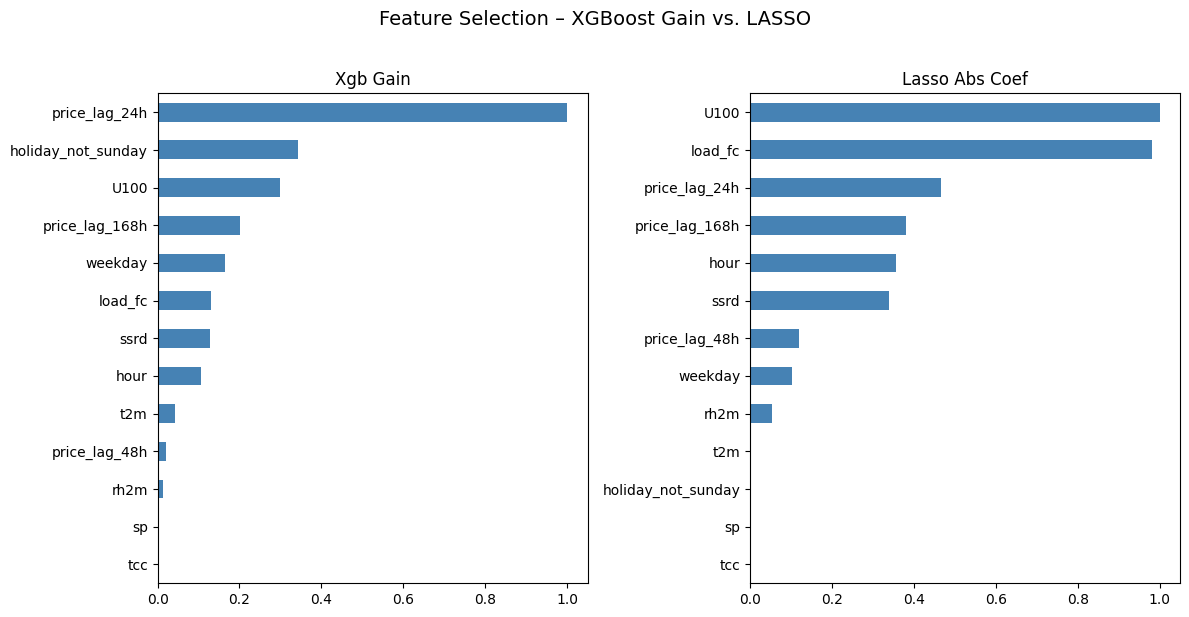

In [ ]:
# ── Feature Selection: Embedded & Wrapper Methods ──────────────────────────

# ── Zyklische Feature-Gruppen ──
cyclic_pairs = {
    "hour":    ["hour_sin", "hour_cos"],
    "weekday": ["weekday_sin", "weekday_cos"],
}
single_features = [f for f in FEATURE_COLS if not any(f in pair for pair in cyclic_pairs.values())]
display_names = single_features + list(cyclic_pairs.keys())

col_idx = {f: i for i, f in enumerate(FEATURE_COLS)}


# ── 1) XGBoost Feature Importance (gain) ──
xgb_fs = XGBRegressor(random_state=1904, n_jobs=-1)
xgb_fs.fit(X_train_point, y_train_point)

raw_xgb = pd.Series(xgb_fs.feature_importances_, index=FEATURE_COLS)
xgb_importance = pd.Series(dtype=float, name="xgb_gain")
for f in single_features:
    xgb_importance[f] = raw_xgb[f]
for name, cols in cyclic_pairs.items():
    xgb_importance[name] = np.sqrt((raw_xgb[cols] ** 2).sum())


# ── 2) LASSO (L1-Regularisierung) ──
lasso = LassoCV(cv=TimeSeriesSplit(n_splits=5), random_state=1904, n_jobs=-1)
lasso.fit(X_train_point, y_train_point)

raw_lasso = pd.Series(np.abs(lasso.coef_), index=FEATURE_COLS)
lasso_coefs = pd.Series(dtype=float, name="lasso_abs_coef")
for f in single_features:
    lasso_coefs[f] = raw_lasso[f]
for name, cols in cyclic_pairs.items():
    lasso_coefs[name] = np.sqrt((raw_lasso[cols] ** 2).sum())


# ── Ranking ──────────────────────────────────────────────────
fs_results = pd.DataFrame({
    "xgb_gain":       xgb_importance,
    "lasso_abs_coef": lasso_coefs,
}, index=display_names)

fs_norm = fs_results.apply(lambda col: (col - col.min()) / (col.max() - col.min()))

print("\n── Feature Selection Ranking ──")
print(fs_norm.round(3).to_string())

# ── Visualisierung ──
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, col in zip(axes, fs_norm.columns):
    fs_norm[col].sort_values().plot.barh(ax=ax, color="steelblue")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlim(0, 1.05)
axes[0].set_ylabel("")
fig.suptitle("Feature Selection – XGBoost Gain vs. LASSO", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### Recursive Feature Elimination


Config: default — sklearn defaults
All 13 features → CV-MAE: 0.1563
  Best candidate: 't2m' → CV-MAE: 0.1519  (Δ = -0.0044)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 'rh2m', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 'rh2m' → CV-MAE: 0.1519  (Δ = -0.0000)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 'U100', 'sp', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 'sp' → CV-MAE: 0.1487  (Δ = -0.0032)
    → Removed. Remaining: ['load_fc', 'ssrd', 'tcc', 'U100', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']
  Best candidate: 'tcc' → CV-MAE: 0.1501  (Δ = +0.0015)
    → No improvement. Stopping.
Final features (10): ['load_fc', 'ssrd', 'tcc', 'U100', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'holiday_not_sunday', 'hour', 'weekday']

Config: deep_slow — {'n_estimators': 300, '

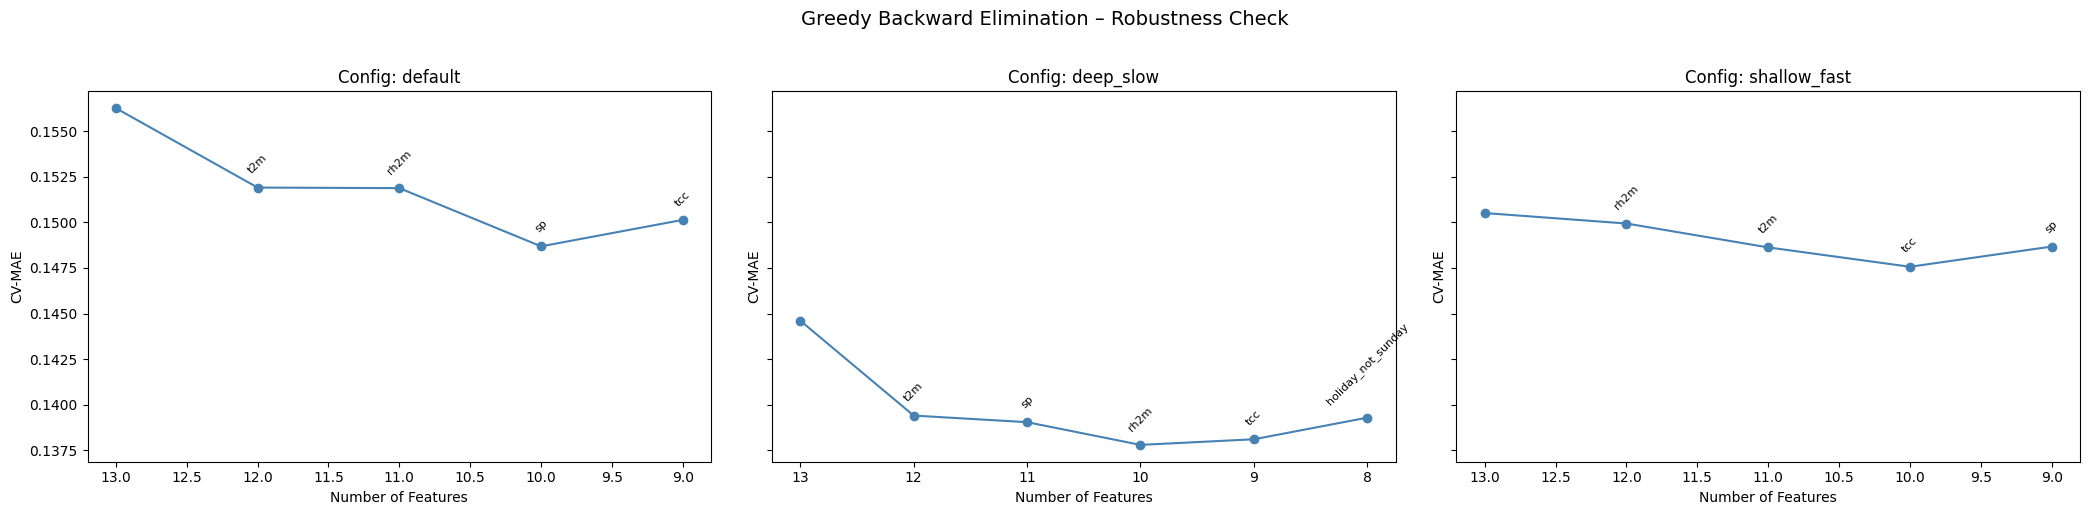

In [ ]:
# ── Greedy Backward Elimination with CV (Multi-Config) ──────────────────────
from sklearn.model_selection import cross_val_score
from collections import Counter

tscv = TimeSeriesSplit(n_splits=5)

def get_col_indices(selected_names):
    indices = []
    for name in selected_names:
        if name in cyclic_pairs:
            indices += [col_idx[c] for c in cyclic_pairs[name]]
        else:
            indices.append(col_idx[name])
    return indices

configs = [
    {"label": "default",      "params": {}},
    {"label": "deep_slow",    "params": {"n_estimators": 300, "max_depth": 5, "learning_rate": 0.05, "subsample": 0.8, "colsample_bytree": 0.8}},
    {"label": "shallow_fast", "params": {"n_estimators": 200, "max_depth": 8, "learning_rate": 0.1}},
]

all_results = {}

for cfg in configs:
    label = cfg["label"]
    print(f"\n{'='*60}")
    print(f"Config: {label} — {cfg['params'] or 'sklearn defaults'}")
    print(f"{'='*60}")

    def cv_mae_for_features(selected_names):
        idx = get_col_indices(selected_names)
        return -cross_val_score(
            XGBRegressor(
                objective="reg:squarederror", random_state=1904, n_jobs=-1,
                **cfg["params"],
            ),
            X_train_point[:, idx], y_train_point,
            cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1,
        ).mean()

    remaining = display_names.copy()
    current_score = cv_mae_for_features(remaining)
    elimination_log = [{"n_features": len(remaining), "removed": None, "cv_mae": current_score}]
    print(f"All {len(remaining)} features → CV-MAE: {current_score:.4f}")

    while len(remaining) > 1:
        trials = []
        for candidate in remaining:
            trial = [f for f in remaining if f != candidate]
            score = cv_mae_for_features(trial)
            trials.append((candidate, score, trial))

        best_candidate, best_score, best_trial = min(trials, key=lambda x: x[1])
        elimination_log.append({"n_features": len(best_trial), "removed": best_candidate, "cv_mae": best_score})

        print(f"  Best candidate: '{best_candidate}' → CV-MAE: {best_score:.4f}  (Δ = {best_score - current_score:+.4f})")

        if best_score <= current_score * 1.005:
            remaining = best_trial
            current_score = best_score
            print(f"    → Removed. Remaining: {remaining}")
        else:
            print(f"    → No improvement. Stopping.")
            break

    all_results[label] = {
        "remaining": remaining,
        "log": pd.DataFrame(elimination_log),
    }
    print(f"Final features ({len(remaining)}): {remaining}")


# ── Summary: how often was each feature removed? ──

removed_counts = Counter()
for label, result in all_results.items():
    removed_in_config = set(display_names) - set(result["remaining"])
    removed_counts.update(removed_in_config)

print(f"\n{'='*60}")
for f in display_names:
    count = removed_counts.get(f, 0)
    if count > 0:
        print(f"  {f}: removed in {count}/{len(configs)} configs")
print(f"{'='*60}")



# ── Visualization ──
fig, axes = plt.subplots(1, len(configs), figsize=(7 * len(configs), 5), sharey=True)
for ax, (label, result) in zip(axes, all_results.items()):
    log_df = result["log"]
    ax.plot(log_df["n_features"], log_df["cv_mae"], "o-", color="steelblue")
    for _, row in log_df.iterrows():
        if row["removed"]:
            ax.annotate(row["removed"], (row["n_features"], row["cv_mae"]),
                        textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center", rotation=45)
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("CV-MAE")
    ax.set_title(f"Config: {label}")
    ax.invert_xaxis()
fig.suptitle("Greedy Backward Elimination – Robustness Check", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The weather features *t2m*, *sp*, *tcc* and *rh2m* have a lack of importance to the basic models. These also have bad results in the importance ranknigs. Only the weather features *U100* and *ssrd* will be kept for the modeling and work as proxies for the wind generation (*U100*) and solar generation (*ssrd*).

### Delete Features

In [6]:
# ── Remove selected variables from existing objects ───────────────────
DROP_COLS = ["t2m", "sp", "tcc", "rh2m"]

# Remember the old order, because the existing arrays still rely on it
old_feature_cols = FEATURE_COLS.copy()

# Kept features + their indices
keep_cols = [c for c in old_feature_cols if c not in DROP_COLS]
keep_idx = [old_feature_cols.index(c) for c in keep_cols]

# Update lists
FEATURE_COLS = keep_cols
SCALE_COLS = [c for c in SCALE_COLS if c not in DROP_COLS]

# Update DataFrames
model_df = model_df.drop(columns=DROP_COLS)
train_df = train_df.drop(columns=DROP_COLS)
test_df = test_df.drop(columns=DROP_COLS)
test_history_df = test_history_df.drop(columns=DROP_COLS)
test_with_history_df = test_with_history_df.drop(columns=DROP_COLS)
val_df = val_df.drop(columns=DROP_COLS)
val_history_df = val_history_df.drop(columns=DROP_COLS)
val_with_history_df = val_with_history_df.drop(columns=DROP_COLS)

# Update point datasets
X_train_point = X_train_point[:, keep_idx]
X_test_point = X_test_point[:, keep_idx]
X_val_point = X_val_point[:, keep_idx]

# Update lookback exog datasets
X_train_exog_lookback = X_train_exog_lookback[:, keep_idx]
X_test_exog_lookback = X_test_exog_lookback[:, keep_idx]
X_val_exog_lookback = X_val_exog_lookback[:, keep_idx]

# Rebuild flat lookback datasets
X_train_flat_lookback = np.concatenate([
    X_train_seq_lookback.reshape(X_train_seq_lookback.shape[0], -1),
    X_train_exog_lookback,
], axis=1)

X_test_flat_lookback = np.concatenate([
    X_test_seq_lookback.reshape(X_test_seq_lookback.shape[0], -1),
    X_test_exog_lookback,
], axis=1)

X_val_flat_lookback = np.concatenate([
    X_val_seq_lookback.reshape(X_val_seq_lookback.shape[0], -1),
    X_val_exog_lookback,
], axis=1)

display(pd.DataFrame([
    {"set": "point", "split": "train", "X": X_train_point.shape, "y": y_train_point.shape},
    {"set": "point", "split": "val", "X": X_val_point.shape, "y": y_val_point.shape},
    {"set": "point", "split": "test", "X": X_test_point.shape, "y": y_test_point.shape},
]))
display(pd.DataFrame([
    {"set": "fixed lookback", "split": "train", "X_seq": X_train_seq_lookback.shape, "X_exog": X_train_exog_lookback.shape, "X_flat": X_train_flat_lookback.shape, "y": y_train_lookback.shape},
    {"set": "fixed lookback", "split": "val",  "X_seq": X_val_seq_lookback.shape,  "X_exog": X_val_exog_lookback.shape,  "X_flat": X_val_flat_lookback.shape,  "y": y_val_lookback.shape},
    {"set": "fixed lookback", "split": "test",  "X_seq": X_test_seq_lookback.shape,  "X_exog": X_test_exog_lookback.shape,  "X_flat": X_test_flat_lookback.shape,  "y": y_test_lookback.shape},
]))


,set,split,X,y
0,point,train,"(17544, 11)","(17544,)"
1,point,val,"(4343, 11)","(4343,)"
2,point,test,"(4417, 11)","(4417,)"


,set,split,X_seq,X_exog,X_flat,y
0,fixed lookback,train,"(17496, 48, 1)","(17496, 11)","(17496, 59)","(17496,)"
1,fixed lookback,val,"(4343, 48, 1)","(4343, 11)","(4343, 59)","(4343,)"
2,fixed lookback,test,"(4417, 48, 1)","(4417, 11)","(4417, 59)","(4417,)"


# Modelling Setup (Rollout Lookback)

In [7]:
# ---------- Rollout-Lookback setup ----------
# Rolling 168h window ending one hour before the target timestamp.
# Rollout models are trained on the same rolling-window layout.
# During test rollout, same-day target values are replaced by earlier predictions.

ROLL_PRICE_COL = "_roll_price"


def to_numpy_float32(values) -> np.ndarray:
    if hasattr(values, "to_numpy"):
        values = values.to_numpy()
    if hasattr(values, "get"):
        values = values.get()
    return np.asarray(values, dtype=np.float32).reshape(-1)


def _steps_within_day(index: pd.DatetimeIndex) -> np.ndarray:
    date_ints = _date_ints_from_index(index)
    steps = np.empty(len(index), dtype=np.int32)
    previous_date = None
    step = -1

    for i, date_int in enumerate(date_ints):
        if date_int != previous_date:
            previous_date = date_int
            step = 0
        else:
            step += 1
        steps[i] = step

    return steps


def build_rolling_lookback_dataset(
    df: pd.DataFrame,
    sequence_cols: list[str],
    exog_cols: list[str],
    target_col: str,
    lookback_hours: int,
):
    """
    For each target timestamp ts, the sequence covers the last `lookback_hours`
    rows ending at ts - 1h. This is the training layout used by rollout models.
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values = df[exog_cols].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)

    X_seq, X_exog, y_target, ts_target = [], [], [], []

    for row_idx in range(lookback_hours, len(df)):
        keep_idx = np.arange(row_idx - lookback_hours, row_idx)
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )


def build_rollout_frame(
    history_df: pd.DataFrame,
    target_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> pd.DataFrame:
    rollout = pd.concat(
        [
            history_df[[target_col]],
            target_df[[target_col] + feature_cols],
        ],
        axis=0,
    ).sort_index()

    if not rollout.index.is_unique:
        raise ValueError("rollout_df index must be unique.")
    if rollout[target_col].isna().any():
        raise ValueError("rollout_df target contains missing values.")

    rollout[ROLL_PRICE_COL] = rollout[target_col].astype(np.float32)
    rollout.loc[target_df.index, ROLL_PRICE_COL] = np.nan
    return rollout


def _rollout_predict(
    rollout_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    predict_batch,
    verbose: bool = False,
) -> np.ndarray:
    target_times = pd.DatetimeIndex(target_times)
    if len(target_times) == 0:
        return np.array([], dtype=np.float32)
    if not target_times.is_monotonic_increasing:
        raise ValueError("target_times must be sorted increasingly for rollout prediction.")

    idx_lookup = {ts: i for i, ts in enumerate(rollout_df.index)}
    missing_times = [ts for ts in target_times if ts not in idx_lookup]
    if missing_times:
        raise KeyError(f"target timestamp missing from rollout_df: {missing_times[0]}")

    target_pos = np.array([idx_lookup[ts] for ts in target_times], dtype=np.int64)
    if np.any(target_pos < lookback_hours):
        raise ValueError("rollout_df does not contain enough history for the requested lookback.")

    roll_price = rollout_df[ROLL_PRICE_COL].to_numpy(dtype=np.float32).copy()
    target_arr = rollout_df[target_col].to_numpy(dtype=np.float32)
    exog_arr = rollout_df[feature_cols].to_numpy(dtype=np.float32)
    date_ints = _date_ints_from_index(rollout_df.index)
    target_date_ints = _date_ints_from_index(target_times)
    target_steps = _steps_within_day(target_times)

    preds = np.zeros(len(target_times), dtype=np.float32)
    lookback_offsets = np.arange(-lookback_hours, 0, dtype=np.int64)
    max_step = int(target_steps.max())

    for step in range(max_step + 1):
        band = np.flatnonzero(target_steps == step)
        if len(band) == 0:
            continue

        pos = target_pos[band]
        hist_pos = pos[:, None] + lookback_offsets
        same_day = date_ints[hist_pos] == target_date_ints[band, None]

        seq = np.where(same_day, roll_price[hist_pos], target_arr[hist_pos]).astype(np.float32)
        if np.isnan(seq).any():
            raise ValueError(
                "Rollout sequence contains NaN. target_times must include previous same-day targets."
            )
        exog = exog_arr[pos].astype(np.float32)

        y_hat = to_numpy_float32(predict_batch(seq, exog))
        if len(y_hat) != len(band):
            raise ValueError("Rollout model returned an unexpected number of predictions.")

        preds[band] = y_hat
        roll_price[pos] = y_hat

        if verbose:
            print(f"  Rollout step {step + 1:02d}/{max_step + 1:02d} - {len(band)} samples")

    return preds


def rollout_predict_tabular(
    model,
    rollout_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    verbose: bool = False,
) -> np.ndarray:
    def predict_batch(seq: np.ndarray, exog: np.ndarray):
        x_batch = np.concatenate([seq, exog], axis=1).astype(np.float32)
        return model.predict(x_batch)

    return _rollout_predict(
        rollout_df,
        target_times,
        feature_cols,
        target_col,
        lookback_hours,
        predict_batch,
        verbose=verbose,
    )


def rollout_predict_keras(
    model,
    rollout_df: pd.DataFrame,
    target_times: pd.DatetimeIndex,
    feature_cols: list[str],
    target_col: str,
    lookback_hours: int,
    verbose: bool = False,
) -> np.ndarray:
    def predict_batch(seq: np.ndarray, exog: np.ndarray):
        keras_inputs = [seq[:, :, None], exog]
        try:
            return model.predict(keras_inputs, verbose=0)
        except TypeError:
            return model.predict(keras_inputs)

    return _rollout_predict(
        rollout_df,
        target_times,
        feature_cols,
        target_col,
        lookback_hours,
        predict_batch,
        verbose=verbose,
    )



# --- build rolling-lookback datasets for rollout models ---
X_train_seq_rollout, X_train_exog_rollout, y_train_rollout, ts_train_rollout = build_rolling_lookback_dataset(
    train_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)

X_test_seq_rollout, X_test_exog_rollout, y_test_rollout_t, ts_test_rollout = build_rolling_lookback_dataset(
    test_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)

X_val_seq_rollout, X_val_exog_rollout, y_val_rollout_t, ts_val_rollout = build_rolling_lookback_dataset(
    val_with_history_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, LOOKBACK,
)


X_train_flat_rollout = np.concatenate([
    X_train_seq_rollout.reshape(X_train_seq_rollout.shape[0], -1),
    X_train_exog_rollout,
], axis=1)
X_test_flat_rollout = np.concatenate([
    X_test_seq_rollout.reshape(X_test_seq_rollout.shape[0], -1),
    X_test_exog_rollout,
], axis=1)
X_val_flat_rollout = np.concatenate([
    X_val_seq_rollout.reshape(X_val_seq_rollout.shape[0], -1),
    X_val_exog_rollout,
], axis=1)

rollout_df = build_rollout_frame(test_history_df, test_df, FEATURE_COLS, TARGET_COL)
test_rollout_index = ts_test_rollout
y_test_rollout = y_test
rollout_df_val = build_rollout_frame(val_history_df, val_df, FEATURE_COLS, TARGET_COL)
val_rollout_index = ts_val_rollout
y_val_rollout = y_val


display(pd.DataFrame([
    {"set": "rollout", "split": "train", "X_seq": X_train_seq_rollout.shape, "X_exog": X_train_exog_rollout.shape, "X_flat": X_train_flat_rollout.shape, "y": y_train_rollout.shape},
    {"set": "rollout", "split": "val", "X_seq": X_val_seq_rollout.shape, "X_exog": X_val_exog_rollout.shape, "X_flat": X_val_flat_rollout.shape, "y": y_val_rollout_t.shape},
    {"set": "rollout", "split": "test", "X_seq": X_test_seq_rollout.shape, "X_exog": X_test_exog_rollout.shape, "X_flat": X_test_flat_rollout.shape, "y": y_test_rollout_t.shape},
]))

,set,split,X_seq,X_exog,X_flat,y
0,rollout,train,"(17496, 48, 1)","(17496, 11)","(17496, 59)","(17496,)"
1,rollout,val,"(4343, 48, 1)","(4343, 11)","(4343, 59)","(4343,)"
2,rollout,test,"(4417, 48, 1)","(4417, 11)","(4417, 59)","(4417,)"


# SARIMAX pre-diagnostic for hyperparameter definition

In [ ]:
# ── Simple pre-diagnostic: decide differencing + derive a compact grid ──
# Decide HOW OFTEN to difference (d, D) from the data.
# The exact AR/MA orders (p, q, P, Q) are left to the AIC grid search,
# but deliberately restricted to small values.

from statsmodels.tsa.stattools import adfuller, kpss
from itertools import product

S = 24  # daily seasonality for hourly data
y = train_df[TARGET_COL]


def is_stationary(series):
    """A series counts as stationary only if ADF AND KPSS agree."""
    adf_p = adfuller(series.dropna())[1]              # H0: non-stationary -> p < 0.05 = stationary
    kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary
    return (adf_p < 0.05) and (kpss_p > 0.05), adf_p, kpss_p


# Decide differencing: seasonal first (against the daily pattern), then regular if needed.
stat_orig, adf0, kpss0 = is_stationary(y)
stat_seas, adf1, kpss1 = is_stationary(y.diff(S).dropna())

d, D = 0, 0
if not stat_orig:
    D = 1                 # seasonal differencing against the daily seasonality
    if not stat_seas:
        d = 1             # additional regular differencing if still not stationary

print(f"Original     : stationary={stat_orig}  (ADF p={adf0:.3f}, KPSS p={kpss0:.3f})")
print(f"Seasonal diff: stationary={stat_seas}  (ADF p={adf1:.3f}, KPSS p={kpss1:.3f})")
print(f"=> chosen differencing: d={d}, D={D}, s={S}\n")

# Compact grid for the AR/MA orders.
search_space = sorted(
    (p, q, P, Q)
    for p, q, P, Q in product([0, 1, 2], [0, 1, 2], [0, 1], [0, 1])    # initial grid with common sense limits to avoid long runtimes
    if (p + q) <= 2 and (P + Q) <= 2                                   # keep the model lean (no overfitting) by limiting total AR+MA orders
    and not ((p >= 2 and P >= 1) or (q >= 2 and Q >= 1))               # avoid known over-parameterization patterns (high non-seasonal + seasonal orders together
)

print(f"Search grid: d={d}, D={D}, s={S}, {len(search_space)} candidates (p,q,P,Q):")
print(search_space)


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_80390/1764809939.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary


Original     : stationary=False  (ADF p=0.000, KPSS p=0.010)
Seasonal diff: stationary=True  (ADF p=0.000, KPSS p=0.100)
=> chosen differencing: d=0, D=1, s=24

Search grid: d=0, D=1, s=24, 20 candidates (p,q,P,Q):
[(0, 0, 0, 0), (0, 0, 0, 1), (0, 0, 1, 0), (0, 0, 1, 1), (0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (0, 1, 1, 1), (0, 2, 0, 0), (0, 2, 1, 0), (1, 0, 0, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 0, 1, 1), (1, 1, 0, 0), (1, 1, 0, 1), (1, 1, 1, 0), (1, 1, 1, 1), (2, 0, 0, 0), (2, 0, 0, 1)]


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_80390/1764809939.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(series.dropna(), nlags="auto")[1]   # H0: stationary     -> p > 0.05 = stationary


# Modelling

## First Training

### XGBoost




In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
xgb_base = dict(
    objective="reg:squarederror",
    random_state=1904,
    n_jobs=-1,
    device="cuda"
)

param_dist = {
    "n_estimators": [100, 200, 400, 500],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "min_child_weight": [1, 3, 5, 7],
}

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# -------------------------------------------------
# Point model tuning
# -------------------------------------------------
search_point = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_point.fit(X_train_point, y_train_point)
xgb_point = search_point.best_estimator_

print("Best params (point):", search_point.best_params_)
print("Best CV score (point):", -search_point.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [06:45:27] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best params (point): {'subsample': 0.6, 'reg_lambda': 0.5, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV score (point): 0.1355477452278137


In [ ]:
# -------------------------------------------------
# Fixed lookback model tuning
# -------------------------------------------------
search_lookback = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_lookback.fit(X_train_flat_lookback, y_train_lookback)
xgb_lookback = search_lookback.best_estimator_

print("Best params (lookback):", search_lookback.best_params_)
print("Best CV score (lookback):", -search_lookback.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [13:52:43] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best params (lookback): {'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV score (lookback): 0.12572363317012786


In [ ]:
# -------------------------------------------------
# Rollout lookback model tuning
# -------------------------------------------------
search_rollout = RandomizedSearchCV(
    estimator=XGBRegressor(**xgb_base),
    param_distributions=param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rollout.fit(X_train_flat_rollout, y_train_rollout)
xgb_rollout = search_rollout.best_estimator_

print("Best params (rollout):", search_rollout.best_params_)
print("Best CV score (rollout):", -search_rollout.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (rollout): {'subsample': 0.6, 'reg_lambda': 2.0, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best CV score (rollout): 0.05632321909070015


In [ ]:
# save models
joblib.dump(xgb_point, "models/xgb_point_model.joblib")
joblib.dump(xgb_lookback, "models/xgb_lookback_model.joblib")
joblib.dump(xgb_rollout, "models/xgb_rollout_model.joblib")

['models/xgb_rollout_model.joblib']

### Random Forest


In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
from cuml.ensemble import RandomForestRegressor as RFRegressor

rf_base = dict(random_state=1904)

rf_param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [8, 12, 16, 20, 32],   # no None: cuML requires int
    "max_features":      [0.33, 0.5, "sqrt"],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_samples":       [0.6, 0.8, 1.0],        # bootstrap fraction
}

tscv = TimeSeriesSplit(n_splits=5)


In [ ]:
# -------------------------------------------------
# Point model tuning
# -------------------------------------------------
search_rf_point = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1
)

search_rf_point.fit(X_train_point, y_train_point)
rf_point = search_rf_point.best_estimator_

print("Best params (RF point):", search_rf_point.best_params_)
print("Best CV MAE  (RF point):", -search_rf_point.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF point): {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 1.0, 'max_features': 0.33, 'max_depth': 12}
Best CV MAE  (RF point): 0.14083043932914735


In [ ]:
# -------------------------------------------------
# Fixed lookback model tuning
# -------------------------------------------------
search_rf_lookback = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rf_lookback.fit(X_train_flat_lookback, y_train_lookback)
rf_lookback = search_rf_lookback.best_estimator_

print("Best params (RF lookback):", search_rf_lookback.best_params_)
print("Best CV MAE  (RF lookback):", -search_rf_lookback.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF lookback): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_samples': 0.8, 'max_features': 0.5, 'max_depth': 20}
Best CV MAE  (RF lookback): 0.13599431216716767


In [ ]:
# -------------------------------------------------
# Rollout lookback model tuning
# -------------------------------------------------
search_rf_rollout = RandomizedSearchCV(
    estimator=RFRegressor(**rf_base),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_rf_rollout.fit(X_train_flat_rollout, y_train_rollout)
rf_rollout = search_rf_rollout.best_estimator_

print("Best params (RF rollout):", search_rf_rollout.best_params_)
print("Best CV MAE  (RF rollout):", -search_rf_rollout.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF rollout): {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_samples': 1.0, 'max_features': 0.5, 'max_depth': 32}
Best CV MAE  (RF rollout): 0.06182406097650528


In [ ]:
# save models
joblib.dump(rf_point, "models/rf_point_model.joblib")
joblib.dump(rf_lookback, "models/rf_lookback_model.joblib")
joblib.dump(rf_rollout, "models/rf_rollout_model.joblib")

['models/rf_rollout_model.joblib']

### Support Vector Machine


In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
from cuml.svm import SVR as SVRModel

svm_param_dist = {
    "C":       [0.1, 1, 10, 100, 1000],
    "epsilon": [0.01, 0.05, 0.1, 0.5, 1.0],
    "gamma":   ["scale", "auto", 0.001, 0.01, 0.1],  # only rbf-kernel because of cuML
}

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# -------------------------------------------------
# Point model tuning
# -------------------------------------------------
search_svm_point = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)
search_svm_point.fit(X_train_point, y_train_point)

svm_point = search_svm_point.best_estimator_

print("Best params (SVM point):", search_svm_point.best_params_)
print("Best CV MAE  (SVM point):", -search_svm_point.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (SVM point): {'gamma': 'auto', 'epsilon': 0.05, 'C': 1}
Best CV MAE  (SVM point): 0.14339711219072343


In [ ]:
# -------------------------------------------------
# Fixed lookback model tuning
# -------------------------------------------------
search_svm_lookback = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_svm_lookback.fit(X_train_flat_lookback, y_train_lookback)
svm_lookback = search_svm_lookback.best_estimator_

print("Best params (SVM lookback):", search_svm_lookback.best_params_)
print("Best CV MAE  (SVM lookback):", -search_svm_lookback.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (SVM lookback): {'gamma': 0.01, 'epsilon': 0.01, 'C': 1}
Best CV MAE  (SVM lookback): 0.13802863657474518


In [ ]:
# -------------------------------------------------
# Rollout lookback model tuning
# -------------------------------------------------
search_svm_rollout = RandomizedSearchCV(
    estimator=SVRModel(kernel="rbf"),
    param_distributions=svm_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    verbose=1,
    random_state=1904,
    n_jobs=1,
)

search_svm_rollout.fit(X_train_flat_rollout, y_train_rollout)
svm_rollout = search_svm_rollout.best_estimator_

print("Best params (SVM rollout):", search_svm_rollout.best_params_)
print("Best CV MAE  (SVM rollout):", -search_svm_rollout.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (SVM rollout): {'gamma': 0.001, 'epsilon': 0.05, 'C': 100}
Best CV MAE  (SVM rollout): 0.05668566972017288


In [ ]:
joblib.dump(svm_point, "models/svm_point_model.joblib")
joblib.dump(svm_lookback, "models/svm_lookback_model.joblib")
joblib.dump(svm_rollout, "models/svm_rollout_model.joblib")

['models/svm_rollout_model.joblib']

###  LSTM




In [ ]:
# -------------------------------------------------
# LSTM builder
# -------------------------------------------------
def build_lstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_lookback.shape[1],))

    hidden = layers.LSTM(
        units=int(params["lstm_units"]),
        dropout=float(params["lstm_dropout"]),
        recurrent_dropout=float(params["recurrent_dropout"]),
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# Holdout evaluation with last 15% of train as validation set
# -------------------------------------------------
def evaluate_lstm_params_on_dataset(
    params,
    X_seq,
    X_exog,
    y,
    val_frac=0.15,
    epochs=40,
    patience=6,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_lstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_seq[tr_idx], X_exog[tr_idx]],
        y[tr_idx],
        validation_data=(
            [X_seq[val_idx], X_exog[val_idx]],
            y[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_seq[val_idx], X_exog[val_idx]],
        y[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


# -------------------------------------------------
# Search space
# -------------------------------------------------
param_dist = {
    "lstm_units": [32, 64, 96, 128],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [64, 128],
}


# -------------------------------------------------
# Manual random search for fixed lookback and rollout
# -------------------------------------------------
n_trials = 30
search_space = list(ParameterSampler(param_dist, n_iter=n_trials, random_state=1904))

results = []
rollout_results = []

print(f"Starte LSTM Hyperparameter-Suche ({n_trials} Trials, Holdout 15%) ...")

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Lookback teste: {params}")

    scores = evaluate_lstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_lookback,
        X_exog=X_train_exog_lookback,
        y=y_train_lookback,
        val_frac=0.15,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    results.append(row)

    print(
        f"    -> Lookback Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Rollout teste: {params}")

    scores = evaluate_lstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_rollout,
        X_exog=X_train_exog_rollout,
        y=y_train_rollout,
        val_frac=0.15,
        epochs=40,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    rollout_results.append(row)

    print(
        f"    -> Rollout Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

rollout_results_df = (
    pd.DataFrame(rollout_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

display(results_df.head(5))
display(rollout_results_df.head(5))

best_params = {k: results_df.loc[0, k] for k in param_dist.keys()}
best_rollout_params = {k: rollout_results_df.loc[0, k] for k in param_dist.keys()}

print("\nBeste LSTM-Hyperparameter (lookback):")
for k, v in best_params.items():
    print(f"  {k}: {v}")

print("\nBeste LSTM-Hyperparameter (rollout):")
for k, v in best_rollout_params.items():
    print(f"  {k}: {v}")

Starte LSTM Hyperparameter-Suche (30 Trials, Holdout 15%) ...
[1/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 64, 'lstm_dropout': 0.0, 'learning_rate': 0.001, 'dense_units': 64, 'dense_dropout': 0.4, 'batch_size': 128}
    -> Lookback Val-MAE_t: 0.1514 | Val-RMSE_t: 0.2096 | Epochs: 15
[2/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 96, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 32, 'dense_dropout': 0.0, 'batch_size': 128}
    -> Lookback Val-MAE_t: 0.1486 | Val-RMSE_t: 0.2141 | Epochs: 12
[3/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 128, 'lstm_dropout': 0.0, 'learning_rate': 0.003, 'dense_units': 32, 'dense_dropout': 0.2, 'batch_size': 64}
    -> Lookback Val-MAE_t: 0.1343 | Val-RMSE_t: 0.1950 | Epochs: 14
[4/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.1, 'learning_rate': 0.003, 'dense_units': 32, 'dense_dropout': 0.0, 'batch_size': 128}
    -> Lookback Val-MAE_t: 0.1397 | Val-RM

,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,128,0.0000,0.0030,128,0.4000,128,0.1304,0.1943,14
1,0.0000,64,0.2000,0.0030,64,0.3000,128,0.1321,0.1915,16
2,0.0000,96,0.1000,0.0010,128,0.3000,64,0.1332,0.1951,27
3,0.0000,128,0.0000,0.0010,64,0.3000,64,0.1337,0.1927,17
4,0.0000,128,0.0000,0.0030,32,0.2000,64,0.1343,0.1950,14


,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,96,0.0000,0.0003,32,0.1000,64,0.0619,0.0949,40
1,0.0000,128,0.0000,0.0010,64,0.3000,64,0.0630,0.0964,40
2,0.0000,128,0.0000,0.0030,128,0.4000,128,0.0648,0.0977,31
3,0.0000,32,0.0000,0.0030,128,0.4000,128,0.0663,0.0986,34
4,0.0000,64,0.0000,0.0010,32,0.4000,64,0.0666,0.1006,34



Beste LSTM-Hyperparameter (lookback):
  lstm_units: 128
  dense_units: 128
  lstm_dropout: 0.0
  dense_dropout: 0.4
  recurrent_dropout: 0.0
  learning_rate: 0.003
  batch_size: 128

Beste LSTM-Hyperparameter (rollout):
  lstm_units: 96
  dense_units: 32
  lstm_dropout: 0.0
  dense_dropout: 0.1
  recurrent_dropout: 0.0
  learning_rate: 0.0003
  batch_size: 64


In [ ]:
# -------------------------------------------------
# Final fit
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

lstm_model = build_lstm(best_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = lstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.15,
    epochs=40,
    batch_size=int(best_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

# Separate rollout model with rollout-specific tuned hyperparameters.
tf.keras.utils.set_random_seed(1904)
lstm_rollout_model = build_lstm(best_rollout_params)

early_stop_rollout = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = lstm_rollout_model.fit(
    [X_train_seq_rollout, X_train_exog_rollout],
    y_train_rollout,
    validation_split=0.15,
    epochs=40,
    batch_size=int(best_rollout_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop_rollout],
    verbose=1,
)


Epoch 1/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.2360 - rmse: 0.3170 - val_loss: 0.1716 - val_rmse: 0.2267
Epoch 2/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1736 - rmse: 0.2267 - val_loss: 0.1569 - val_rmse: 0.2089
Epoch 3/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1587 - rmse: 0.2093 - val_loss: 0.1489 - val_rmse: 0.2047
Epoch 4/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1529 - rmse: 0.2016 - val_loss: 0.1507 - val_rmse: 0.2039
Epoch 5/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1469 - rmse: 0.1952 - val_loss: 0.1378 - val_rmse: 0.1959
Epoch 6/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1451 - rmse: 0.1943 - val_loss: 0.1402 - val_rmse: 0.2003
Epoch 7/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1432 - rmse: 0.1925 - val_loss: 0.1355 - val_rmse: 0.1958
Epoch 8/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1390 - rmse: 0.1886 - val_loss: 0.1310 - val_rmse: 0.1938
Epoch 9/40
117/117 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# save lstm models
joblib.dump(lstm_model, "models/lstm_model.joblib")
joblib.dump(lstm_rollout_model, "models/lstm_rollout_model.joblib")

['models/lstm_rollout_model.joblib']

###  BiLSTM

In [ ]:
# -------------------------------------------------
# BiLSTM builder
# -------------------------------------------------
def build_bilstm(params):
    input_seq = layers.Input(shape=(LOOKBACK, X_train_seq_lookback.shape[2]))
    input_exog = layers.Input(shape=(X_train_exog_lookback.shape[1],))

    hidden = layers.Bidirectional(
        layers.LSTM(
            units=int(params["lstm_units"]),
            dropout=float(params["lstm_dropout"]),
            recurrent_dropout=float(params["recurrent_dropout"]),
        )
    )(input_seq)

    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)

    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model


# -------------------------------------------------
# Holdout evaluation with last 15% of train as validation set
# -------------------------------------------------
def evaluate_bilstm_params_on_dataset(
    params,
    X_seq,
    X_exog,
    y,
    val_frac=0.15,
    epochs=40,
    patience=6,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)

    n = len(y)
    n_val = int(n * val_frac)
    tr_idx = np.arange(0, n - n_val)
    val_idx = np.arange(n - n_val, n)

    model = build_bilstm(params)
    es = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
    )

    history = model.fit(
        [X_seq[tr_idx], X_exog[tr_idx]],
        y[tr_idx],
        validation_data=(
            [X_seq[val_idx], X_exog[val_idx]],
            y[val_idx],
        ),
        epochs=epochs,
        batch_size=int(params["batch_size"]),
        shuffle=False,
        callbacks=[es],
        verbose=0,
    )

    eval_out = model.evaluate(
        [X_seq[val_idx], X_exog[val_idx]],
        y[val_idx],
        verbose=0,
        return_dict=True,
    )

    epochs_ran = len(history.history["loss"])

    del model, history
    gc.collect()

    return {
        "mae_t": float(eval_out["loss"]),
        "rmse_t": float(eval_out["rmse"]),
        "epochs_ran": epochs_ran,
    }


# -------------------------------------------------
# Search space
# -------------------------------------------------
bilstm_param_dist = {
    "lstm_units": [32, 48, 64, 96],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.1, 0.2, 0.3],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 5e-4, 1e-3, 2e-3],
    "batch_size": [32, 64],
}


# -------------------------------------------------
# Manual random search for fixed lookback and rollout
# -------------------------------------------------
n_trials = 30
search_space = list(ParameterSampler(bilstm_param_dist, n_iter=n_trials, random_state=1904))

bilstm_results = []
bilstm_rollout_results = []

print(f"Starte BiLSTM Hyperparameter-Suche ({n_trials} Trials, Holdout 15%) ...")

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Lookback teste: {params}")

    scores = evaluate_bilstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_lookback,
        X_exog=X_train_exog_lookback,
        y=y_train_lookback,
        val_frac=0.15,
        epochs=50,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    bilstm_results.append(row)

    print(
        f"    -> Lookback Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

for i, params in enumerate(search_space, start=1):
    print(f"[{i}/{n_trials}] Rollout teste: {params}")

    scores = evaluate_bilstm_params_on_dataset(
        params=params,
        X_seq=X_train_seq_rollout,
        X_exog=X_train_exog_rollout,
        y=y_train_rollout,
        val_frac=0.15,
        epochs=50,
        patience=6,
    )

    row = params.copy()
    row["val_mae_t"] = scores["mae_t"]
    row["val_rmse_t"] = scores["rmse_t"]
    row["epochs_ran"] = scores["epochs_ran"]
    bilstm_rollout_results.append(row)

    print(
        f"    -> Rollout Val-MAE_t: {row['val_mae_t']:.4f} | "
        f"Val-RMSE_t: {row['val_rmse_t']:.4f} | "
        f"Epochs: {row['epochs_ran']}"
    )

bilstm_results_df = (
    pd.DataFrame(bilstm_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

bilstm_rollout_results_df = (
    pd.DataFrame(bilstm_rollout_results)
    .sort_values(["val_mae_t", "val_rmse_t"])
    .reset_index(drop=True)
)

display(bilstm_results_df.head(5))
display(bilstm_rollout_results_df.head(5))

best_bilstm_params = {k: bilstm_results_df.loc[0, k] for k in bilstm_param_dist.keys()}
best_bilstm_rollout_params = {k: bilstm_rollout_results_df.loc[0, k] for k in bilstm_param_dist.keys()}

print("\nBeste BiLSTM-Hyperparameter (lookback):")
for k, v in best_bilstm_params.items():
    print(f"  {k}: {v}")

print("\nBeste BiLSTM-Hyperparameter (rollout):")
for k, v in best_bilstm_rollout_params.items():
    print(f"  {k}: {v}")

Starte BiLSTM Hyperparameter-Suche (30 Trials, Holdout 15%) ...
[1/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 96, 'lstm_dropout': 0.0, 'learning_rate': 0.0003, 'dense_units': 32, 'dense_dropout': 0.1, 'batch_size': 64}
    -> Lookback Val-MAE_t: 0.1442 | Val-RMSE_t: 0.2034 | Epochs: 16
[2/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.001, 'dense_units': 128, 'dense_dropout': 0.2, 'batch_size': 32}
    -> Lookback Val-MAE_t: 0.1371 | Val-RMSE_t: 0.1950 | Epochs: 14
[3/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 32, 'lstm_dropout': 0.2, 'learning_rate': 0.002, 'dense_units': 128, 'dense_dropout': 0.1, 'batch_size': 64}
    -> Lookback Val-MAE_t: 0.1385 | Val-RMSE_t: 0.1947 | Epochs: 28
[4/30] Lookback teste: {'recurrent_dropout': 0.0, 'lstm_units': 64, 'lstm_dropout': 0.0, 'learning_rate': 0.002, 'dense_units': 32, 'dense_dropout': 0.1, 'batch_size': 32}
    -> Lookback Val-MAE_t: 0.1265 | Val-R

,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,64,0.0000,0.0020,32,0.1000,32,0.1265,0.1826,28
1,0.0000,48,0.0000,0.0010,64,0.2000,32,0.1300,0.1879,42
2,0.0000,64,0.2000,0.0020,64,0.3000,64,0.1308,0.1889,20
3,0.0000,32,0.0000,0.0020,32,0.1000,32,0.1309,0.1880,35
4,0.0000,48,0.1000,0.0020,64,0.3000,32,0.1310,0.1886,27


,recurrent_dropout,lstm_units,lstm_dropout,learning_rate,dense_units,dense_dropout,batch_size,val_mae_t,val_rmse_t,epochs_ran
0,0.0000,96,0.0000,0.0003,64,0.1000,64,0.0630,0.0958,50
1,0.0000,32,0.0000,0.0020,32,0.1000,32,0.0666,0.1027,25
2,0.0000,96,0.0000,0.0003,32,0.1000,64,0.0670,0.1008,35
3,0.0000,96,0.0000,0.0003,64,0.3000,32,0.0686,0.1007,20
4,0.0000,64,0.0000,0.0010,128,0.3000,64,0.0686,0.1016,16



Beste BiLSTM-Hyperparameter (lookback):
  lstm_units: 64
  dense_units: 32
  lstm_dropout: 0.0
  dense_dropout: 0.1
  recurrent_dropout: 0.0
  learning_rate: 0.002
  batch_size: 32

Beste BiLSTM-Hyperparameter (rollout):
  lstm_units: 96
  dense_units: 64
  lstm_dropout: 0.0
  dense_dropout: 0.1
  recurrent_dropout: 0.0
  learning_rate: 0.0003
  batch_size: 64


In [ ]:
# -------------------------------------------------
# Final fit
# -------------------------------------------------
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)

bilstm_model = build_bilstm(best_bilstm_params)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = bilstm_model.fit(
    [X_train_seq_lookback, X_train_exog_lookback],
    y_train_lookback,
    validation_split=0.15,
    epochs=50,
    batch_size=int(best_bilstm_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop],
    verbose=1,
)

# Separate rollout model with rollout-specific tuned hyperparameters.
tf.keras.utils.set_random_seed(1904)
bilstm_rollout_model = build_bilstm(best_bilstm_rollout_params)

early_stop_rollout = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
)

_ = bilstm_rollout_model.fit(
    [X_train_seq_rollout, X_train_exog_rollout],
    y_train_rollout,
    validation_split=0.15,
    epochs=50,
    batch_size=int(best_bilstm_rollout_params["batch_size"]),
    shuffle=False,
    callbacks=[early_stop_rollout],
    verbose=1,
)


Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.2025 - rmse: 0.2808 - val_loss: 0.1438 - val_rmse: 0.2006
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1524 - rmse: 0.2043 - val_loss: 0.1403 - val_rmse: 0.1966
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1420 - rmse: 0.1907 - val_loss: 0.1388 - val_rmse: 0.1906
Epoch 4/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1359 - rmse: 0.1851 - val_loss: 0.1376 - val_rmse: 0.1920
Epoch 5/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1312 - rmse: 0.1797 - val_loss: 0.1343 - val_rmse: 0.1882
Epoch 6/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1273 - rmse: 0.1756 - val_loss: 0.1357 - val_rmse: 0.1870
Epoch 7/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1246 - rmse: 0.1730 - val_loss: 0.1330 - val_rmse: 0.1875
Epoch 8/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1242 - rmse: 0.1726 - val_loss: 0.1348 - val_rmse: 0.1861
Epoch 9/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
joblib.dump(bilstm_model, "models/bilstm_model.joblib")
joblib.dump(bilstm_rollout_model, "models/bilstm_rollout_model.joblib")

['models/bilstm_rollout_model.joblib']

### SARIMAX

In [14]:
# -------------------------------------------------
# Hyperparameter tuning (AIC grid search)
# -------------------------------------------------

sarimax_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_train  = train_df[FEATURE_COLS].astype(np.float64).asfreq("h")

try:
    search_space
except NameError:
    search_space = [
        (p, q, P, Q)
        for p, q, P, Q in product([0,1,2], [0,1,2], [0,1], [0,1])
        if (p + q) <= 2 and (P + Q) <= 2
        and not ((p >= 2 and P >= 1) or (q >= 2 and Q >= 1))
    ]

RESULTS_PATH = "data/sarimax_gridsearch_results.csv"

# Resume: load existing results
if os.path.exists(RESULTS_PATH):
    candidates = pd.read_csv(RESULTS_PATH).to_dict("records")
    done_keys = {(int(r["p"]), int(r["q"]), int(r["P"]), int(r["Q"])) for r in candidates}
    print(f"Resuming: {len(done_keys)}/{len(search_space)} candidates already done.")
else:
    candidates = []
    done_keys = set()

for i, (p, q, P, Q) in enumerate(search_space):
    tag = f"({p},0,{q})({P},1,{Q},24)"
    if (p, q, P, Q) in done_keys:
        print(f"[{i+1}/{len(search_space)}] {tag}  skipped (done)")
        continue
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            m = SARIMAX(
                endog=sarimax_endog_train,
                exog=sarimax_exog_train,
                order=(p, 0, q),
                seasonal_order=(P, 1, Q, 24),
                trend="n",
            ).fit(disp=False, maxiter=100, method="lbfgs")

        rv = m.mle_retvals
        warn_names = sorted({w.category.__name__ for w in caught})
        candidates.append({
            "p": p, "q": q, "P": P, "Q": Q,
            "aic": m.aic, "bic": m.bic,
            "converged": rv.get("converged"),
            "warnflag":  rv.get("warnflag"),
            "warnings":  "; ".join(warn_names),
        })
        done_keys.add((p, q, P, Q))
        pd.DataFrame(candidates).to_csv(RESULTS_PATH, index=False)

        print(f"[{i+1}/{len(search_space)}] {tag}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  "
              f"converged={rv.get('converged')}")
        for w in caught:
            print(f"        \u26a0 {w.category.__name__}: {str(w.message).splitlines()[0]}")

    except Exception as e:
        print(f"[{i+1}/{len(search_space)}] {tag}  FAILED: {e}")

tuning_df = pd.DataFrame(candidates).sort_values("aic").reset_index(drop=True)
print("\nTop 5 candidates:")
print(tuning_df.head(5))

best = tuning_df.iloc[0]
SARIMAX_ORDER    = (int(best["p"]), 0, int(best["q"]))
SARIMAX_SEASONAL = (int(best["P"]), 1, int(best["Q"]), 24)
print(f"\nBest order: SARIMAX{SARIMAX_ORDER}{SARIMAX_SEASONAL}")

Resuming: 6/20 candidates already done.
[1/20] (0,0,0)(0,1,0,24)  skipped (done)
[2/20] (0,0,0)(0,1,1,24)  skipped (done)
[3/20] (0,0,0)(1,1,0,24)  skipped (done)
[4/20] (0,0,0)(1,1,1,24)  skipped (done)
[5/20] (0,0,1)(0,1,0,24)  skipped (done)
[6/20] (0,0,1)(0,1,1,24)  skipped (done)
[7/20] (0,0,1)(1,1,0,24)  AIC=-23973.0  BIC=-23864.2  converged=True
        ⚠ UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
[8/20] (0,0,1)(1,1,1,24)  AIC=-27050.2  BIC=-26933.6  converged=False
        ⚠ UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
        ⚠ ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
[9/20] (0,0,2)(0,1,0,24)  AIC=-28381.7  BIC=-28272.9  converged=True
[10/20] (0,0,2)(1,1,0,24)  AIC=-30186.7  BIC=-30070.1  converged=True
[11/20] (1,0,0)(0,1,0,24)  AIC=-33687.8  BIC=-33586.8  converged=True
[12/20] (1,0,0)(0,1,1,24)  AIC=-37913.0  BIC=-37804.2  con

All top 5 candidates didn't converged. -> Another tuning with these 5 candidates with higher max iterations and more robust method "nm":

In [16]:
# -------------------------------------------------
# Re-tuning: top-5 candidates with more iterations (maxiter=300)
# -------------------------------------------------

RETUNE_PATH = "data/sarimax_gridsearch_top5_retuned.csv"

top5 = tuning_df.head(5)[["p", "q", "P", "Q"]].astype(int)

# Resume: load already computed results
if os.path.exists(RETUNE_PATH):
    refit_results = pd.read_csv(RETUNE_PATH).to_dict("records")
    done_keys = {(int(r["p"]), int(r["q"]), int(r["P"]), int(r["Q"])) for r in refit_results}
    print(f"Resuming: {len(done_keys)}/{len(top5)} candidates already done.")
else:
    refit_results = []
    done_keys = set()

for p, q, P, Q in top5.itertuples(index=False):
    p, q, P, Q = int(p), int(q), int(P), int(Q)
    tag = f"({p},0,{q})({P},1,{Q},24)"
    if (p, q, P, Q) in done_keys:
        print(f"{tag}  skipped (done)")
        continue
    try:
        # capture warnings (do not suppress) so they can be shown per candidate
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            m = SARIMAX(
                endog=sarimax_endog_train,
                exog=sarimax_exog_train,
                order=(p, 0, q),
                seasonal_order=(P, 1, Q, 24),
                trend="n",
            ).fit(disp=False, maxiter=300, method="lbfgs")

        rv = m.mle_retvals
        warn_names = sorted({w.category.__name__ for w in caught})
        refit_results.append({
            "p": p, "q": q, "P": P, "Q": Q,
            "aic": m.aic, "bic": m.bic,
            "converged": rv.get("converged"),
            "warnflag":  rv.get("warnflag"),
            "warnings":  "; ".join(warn_names),
        })
        done_keys.add((p, q, P, Q))
        pd.DataFrame(refit_results).to_csv(RETUNE_PATH, index=False)     # save after each fit
        print(f"{tag}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  "
              f"converged={rv.get('converged')}  warnflag={rv.get('warnflag')}")
        # show this candidate's warnings (one line per warning)
        for w in caught:
            print(f"        \u26a0 {w.category.__name__}: {str(w.message).splitlines()[0]}")
    except Exception as e:
        print(f"{tag}  FAILED: {e}")

refit_df = pd.DataFrame(refit_results)

# Compare against the original grid (maxiter=100)
prev = tuning_df[["p", "q", "P", "Q", "aic"]].rename(columns={"aic": "aic_maxiter100"})
refit_df = refit_df.merge(prev, on=["p", "q", "P", "Q"], how="left")
refit_df["aic_delta"] = refit_df["aic"] - refit_df["aic_maxiter100"]   # < 0 = improved by more iterations
refit_df = refit_df.sort_values("aic").reset_index(drop=True)

print("\nTop-5 re-tuned (maxiter=300), sorted by AIC:")
print(refit_df)

(1,0,1)(1,1,1,24)  AIC=-38934.9  BIC=-38810.6  converged=True  warnflag=0
(1,0,1)(0,1,1,24)  AIC=-38892.7  BIC=-38776.1  converged=True  warnflag=0
(2,0,0)(0,1,1,24)  AIC=-38839.5  BIC=-38723.0  converged=True  warnflag=0
(1,0,0)(1,1,1,24)  AIC=-37979.3  BIC=-37862.8  converged=True  warnflag=0
(1,0,0)(0,1,1,24)  AIC=-37913.1  BIC=-37804.3  converged=True  warnflag=0

Top-5 re-tuned (maxiter=300), sorted by AIC:
   p  q  P  Q          aic          bic  converged  warnflag warnings  \
0  1  1  1  1 -38,934.9192 -38,810.5816       True         0            
1  1  1  0  1 -38,892.7152 -38,776.1487       True         0            
2  2  0  0  1 -38,839.5284 -38,722.9619       True         0            
3  1  0  1  1 -37,979.3194 -37,862.7530       True         0            
4  1  0  0  1 -37,913.1074 -37,804.3120       True         0            

   aic_maxiter100  aic_delta  
0    -38,918.9487   -15.9706  
1    -38,889.1554    -3.5598  
2    -38,836.4671    -3.0613  
3    -37,964.3443   -

In [ ]:
# -------------------------------------------------
# Model with tuned order
# -------------------------------------------------
sarimax_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_train  = train_df[FEATURE_COLS].astype(np.float64).asfreq("h")

SARIMAX_ORDER    = (1, 0, 1)
SARIMAX_SEASONAL = (1, 1, 1, 24)

sarimax_iter = {"i": 0}
def sarimax_callback(params):
    sarimax_iter["i"] += 1

    if sarimax_iter["i"] == 1 or sarimax_iter["i"] % 5 == 0:
        print(f"SARIMAX iteration {sarimax_iter['i']}")


sarimax_spec = SARIMAX(
    endog=sarimax_endog_train,
    exog=sarimax_exog_train,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    trend="n",
)

sarimax_fit = sarimax_spec.fit(
    disp=True,
    maxiter=500,
    method="lbfgs",
    callback=sarimax_callback
)

print(sarimax_fit.summary())
print(sarimax_fit.mle_retvals)


# Save params of final fitted model
np.save("models/sarimax_params.npy", np.asarray(sarimax_fit.params, dtype=np.float64))

SARIMAX iteration 1
SARIMAX iteration 5
SARIMAX iteration 10
SARIMAX iteration 15
SARIMAX iteration 20
SARIMAX iteration 25
SARIMAX iteration 30
SARIMAX iteration 35
SARIMAX iteration 40
SARIMAX iteration 45
SARIMAX iteration 50
SARIMAX iteration 55
SARIMAX iteration 60
SARIMAX iteration 65
SARIMAX iteration 70
SARIMAX iteration 75
SARIMAX iteration 80
SARIMAX iteration 85
SARIMAX iteration 90
SARIMAX iteration 95
SARIMAX iteration 100
SARIMAX iteration 105
SARIMAX iteration 110
SARIMAX iteration 115
SARIMAX iteration 120
SARIMAX iteration 125
SARIMAX iteration 130
SARIMAX iteration 135
SARIMAX iteration 140
SARIMAX iteration 145
SARIMAX iteration 150
SARIMAX iteration 155
SARIMAX iteration 160
SARIMAX iteration 165
SARIMAX iteration 170
SARIMAX iteration 175
SARIMAX iteration 180
SARIMAX iteration 185
                                     SARIMAX Results                                      
Dep. Variable:                           da_price   No. Observations:                17544
Mode

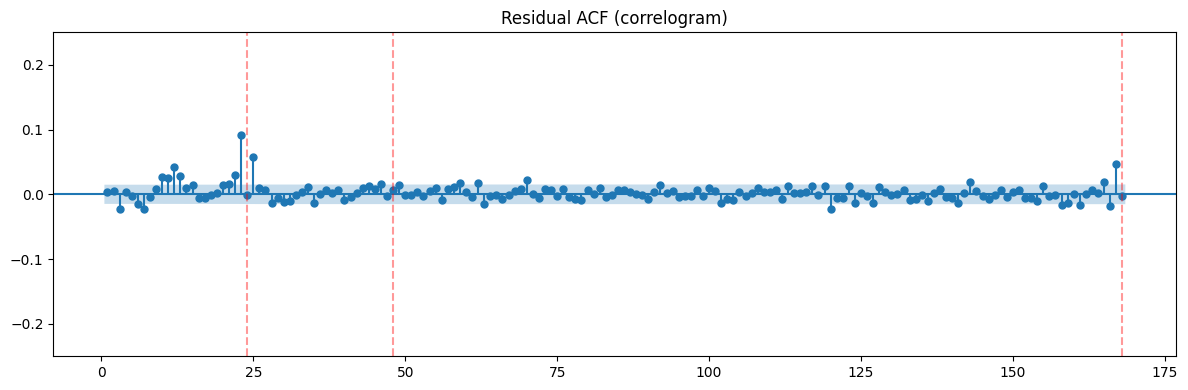

In [9]:
# -------------------------------------------------
# Post-fit diagnostic: residual autocorrelation (correlogram)
# -------------------------------------------------
# If the chosen order is adequate, residuals should be white noise:
# no leftover autocorrelation at any lag, especially the seasonal lags 24 / 168.
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt

# drop the first 24 residuals (state-space initialization artifacts)
resid = sarimax_fit.resid[24:]

# correlogram
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(resid, lags=168, zero=False, ax=ax, title="Residual ACF (correlogram)")
for lag in (24, 48, 168):
    ax.axvline(lag, color="red", linestyle="--", alpha=0.4)
ax.set_ylim(-0.25, 0.25)
plt.tight_layout()
plt.show()

Overall the residuals are close to white noise, indicating a good order. There are only notable spikes around 24h, a typical side-band- artefact of the multiple seasonal structure.

### ARIMA

In [ ]:
import pmdarima as pm
from pmdarima.arima.utils import ndiffs

# -------------------------------------------------
# Hyperparameter tuning (stepwise AIC search via pmdarima)
# -------------------------------------------------
arima_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh-transformed target

d = ndiffs(arima_endog_train, test="kpss") 

auto_model = pm.auto_arima(
    arima_endog_train,
    seasonal=False,            # ARIMA no SARIMA
    d=d,  
    with_intercept=(d == 0),   # if d==1 intercept makes no sense, because no linear trend in price
    max_order=None,            # keine Beschränkung auf p+q <= 5
    stepwise=True,             
    information_criterion="aic",
    maxiter=1000,
    method="nm",
    trace=True,                
    suppress_warnings=False,
    error_action="trace",
)
print(auto_model.summary())
ARIMA_ORDER = auto_model.order
print("Best ARIMA order:", ARIMA_ORDER)
print("With intercept:", auto_model.with_intercept)

Performing stepwise search to minimize aic


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(2,1,2)(0,0,0)[0]             : AIC=-29846.357, Time=15.89 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-21831.102, Time=0.25 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=-27556.966, Time=0.57 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=-27031.060, Time=0.68 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-27957.589, Time=3.11 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-29841.071, Time=2.45 sec


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(3,1,2)(0,0,0)[0]             : AIC=inf, Time=12.28 sec


...

 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-28105.292, Time=6.38 sec


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(3,1,3)(0,0,0)[0]             : AIC=-28378.064, Time=10.47 sec


/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-28024.172, Time=12.25 sec

Best model:  ARIMA(2,1,2)(0,0,0)[0]          
Total fit time: 80.793 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                17544
Model:               SARIMAX(2, 1, 2)   Log Likelihood               14928.178
Date:                Fri, 31 Jul 2026   AIC                         -29846.357
Time:                        14:51:33   BIC                         -29807.495
Sample:                    01-01-2023   HQIC                        -29833.561
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4596      0.008    188.965      0.000       1.

In [57]:
# -------------------------------------------------
# Model with tuned order
# -------------------------------------------------
from statsmodels.tsa.arima.model import ARIMA

ARIMA_ORDER = (2, 1, 2)  # best order from auto_arima
INTERCEPT = "n"

arima_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh-transformed target
arima_endog_test  = test_df[TARGET_COL].astype(np.float64)

arima_fit = ARIMA(
    arima_endog_train,
    order=ARIMA_ORDER,
    trend=INTERCEPT,
).fit(method_kwargs={"maxiter": 1000, "method": "nm"})

/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/envs/entsoe/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [61]:
# save model
arima_fit.save("models/arima_fit.pkl")

## Validation

In [ ]:
# ── Validation: load all models and evaluate them on the validation set ──
records = []

# ---------- Tabular models: XGBoost / RandomForest / SVM ----------
# each has a point, a fixed-lookback and a rollout variant
for name in ["xgb", "rf", "svm"]:
    point    = joblib.load(f"models/{name}_point_model.joblib")
    lookback = joblib.load(f"models/{name}_lookback_model.joblib")
    rollout  = joblib.load(f"models/{name}_rollout_model.joblib")

    y_point    = asinh_inverse(to_numpy_float32(point.predict(X_val_point)), c)
    y_lookback = asinh_inverse(to_numpy_float32(lookback.predict(X_val_flat_lookback)), c)
    y_rollout  = asinh_inverse(
        rollout_predict_tabular(
            rollout, rollout_df_val, val_rollout_index, FEATURE_COLS, TARGET_COL, LOOKBACK
        ),
        c,
    )

    records += [
        {"model": f"{name}_point",    "mae": mae_score(y_val, y_point),           "rmse": rmse_score(y_val, y_point)},
        {"model": f"{name}_lookback", "mae": mae_score(y_val, y_lookback),        "rmse": rmse_score(y_val, y_lookback)},
        {"model": f"{name}_rollout",  "mae": mae_score(y_val_rollout, y_rollout), "rmse": rmse_score(y_val_rollout, y_rollout)},
    ]

# ---------- Sequence models: LSTM / BiLSTM ----------
for name in ["lstm", "bilstm"]:
    model         = joblib.load(f"models/{name}_model.joblib")
    rollout_model = joblib.load(f"models/{name}_rollout_model.joblib")

    y_seq = asinh_inverse(
        to_numpy_float32(model.predict([X_val_seq_lookback, X_val_exog_lookback], verbose=0)),
        c,
    )
    y_seq_rollout = asinh_inverse(
        rollout_predict_keras(
            rollout_model, rollout_df_val, val_rollout_index, FEATURE_COLS, TARGET_COL, LOOKBACK
        ),
        c,
    )

    records += [
        {"model": name,              "mae": mae_score(y_val, y_seq),                 "rmse": rmse_score(y_val, y_seq)},
        {"model": f"{name}_rollout", "mae": mae_score(y_val_rollout, y_seq_rollout), "rmse": rmse_score(y_val_rollout, y_seq_rollout)},
    ]

# ---------- SARIMAX (day-by-day multi-step forecast) ----------

# load model
sarimax_endog_train = train_df[TARGET_COL].astype(np.float64).asfreq("h")
sarimax_exog_train  = train_df[FEATURE_COLS].astype(np.float64).asfreq("h")

params = np.load("models/sarimax_params.npy")
spec = SARIMAX(
    endog=sarimax_endog_train, exog=sarimax_exog_train,
    order=(1, 0, 1), seasonal_order=(1, 1, 1, 24), trend="n",
)
sarimax_model = spec.smooth(params)



sarimax_endog_val = val_df[TARGET_COL].astype(np.float64)
sarimax_exog_val  = val_df[FEATURE_COLS].astype(np.float64)

# Forecast one local delivery day at a time. DST days can have 23 or 25 hours.
val_dates = pd.date_range(
    start=VAL_START.normalize(),
    end=VAL_END.normalize() - pd.DateOffset(days=1),
    freq="D",
)

sarimax_preds_t = {}
running_res = sarimax_model  # starts from the end of the training data
for day in val_dates:
    next_day = day + pd.DateOffset(days=1)
    day_mask = (sarimax_exog_val.index >= day) & (sarimax_exog_val.index < next_day)
    exog_day = sarimax_exog_val.loc[day_mask].sort_index().asfreq("h")

    if len(exog_day) == 0 or exog_day.isna().any().any():
        print(f"WARNING: {day.date()} skipped (missing exog).")
        continue

    forecast = running_res.get_forecast(steps=len(exog_day), exog=exog_day)
    for ts, val in forecast.predicted_mean.items():
        sarimax_preds_t[ts] = val

    actual_day = sarimax_endog_val.reindex(exog_day.index)
    if actual_day.isna().any():
        print(f"WARNING: {day.date()} state not updated (missing actuals).")
        continue
    running_res = running_res.extend(endog=actual_day, exog=exog_day)

sarimax_t = pd.Series(sarimax_preds_t, dtype=np.float64).sort_index().reindex(val_df.index)
if sarimax_t.isna().any():
    raise ValueError(f"SARIMAX forecast is missing {int(sarimax_t.isna().sum())} validation timestamps.")
y_pred_sarimax = asinh_inverse(sarimax_t, c)

records.append(
    {"model": "sarimax",
     "mae":  mae_score(y_val, y_pred_sarimax.to_numpy()),
     "rmse": rmse_score(y_val, y_pred_sarimax.to_numpy())}
)

# ---------- Naive 24h baseline ----------
y_pred_naive24 = data.loc[val_df.index, "price_lag_24h"].to_numpy(dtype=np.float32)
if np.isnan(y_pred_naive24).any():
    raise ValueError("naive 24h baseline contains NaNs in the validation window.")
records.append(
    {"model": "naive_24h",
     "mae":  mae_score(y_val, y_pred_naive24),
     "rmse": rmse_score(y_val, y_pred_naive24)}
)

# ---------- ARIMA (day-by-day multi-step forecast) ----------
arima_model = ARIMAResults.load("models/arima_fit.pkl")
arima_endog_val = val_df[TARGET_COL].astype(np.float64).asfreq("h")

arima_preds_t = {}
running_res = arima_model  # starts from the end of the training data
for day in val_dates:                      # val_dates is already defined in the SARIMAX block above
    next_day = day + pd.DateOffset(days=1)
    mask = (arima_endog_val.index >= day) & (arima_endog_val.index < next_day)
    day_idx = arima_endog_val.loc[mask].sort_index().asfreq("h").index
    if len(day_idx) == 0:
        continue
    forecast = running_res.get_forecast(steps=len(day_idx))
    for ts, val in zip(day_idx, forecast.predicted_mean):
        arima_preds_t[ts] = val
    actual_day = arima_endog_val.reindex(day_idx)
    if actual_day.isna().any():
        continue
    running_res = running_res.extend(endog=actual_day)

arima_t = pd.Series(arima_preds_t, dtype=np.float64).sort_index().reindex(val_df.index)
if arima_t.isna().any():
    raise ValueError(f"ARIMA forecast is missing {int(arima_t.isna().sum())} validation timestamps.")
y_pred_arima = asinh_inverse(arima_t, c)

records.append(
    {"model": "arima",
     "mae":  mae_score(y_val, y_pred_arima.to_numpy()),
     "rmse": rmse_score(y_val, y_pred_arima.to_numpy())}
)

# ---------- Combined score table ----------
scores = pd.DataFrame(records).sort_values("mae", ignore_index=True)
display(scores)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [16:19:59] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,model,mae,rmse
0,sarimax,15.9858,24.0379
1,xgb_lookback,16.8330,26.0840
2,rf_lookback,17.2500,27.0209
3,xgb_point,17.4681,26.6586
4,lstm,17.6224,27.3343
5,rf_point,17.6903,26.8617
6,bilstm,17.7607,27.1337
7,svm_point,17.8225,27.1824
8,svm_lookback,17.9972,27.1414
9,svm_rollout,19.4113,28.8360


In [ ]:
display_scores = scores.copy()

models_to_keep = [
    "xgb_lookback",
    "xgb_rollout",
    "xgb_point",
    "rf_lookback",
    "rf_rollout",
    "rf_point",
    "svm_lookback",
    "svm_rollout",
    "svm_point",
    "bilstm",
    "bilstm_rollout",
    "lstm",
    "lstm_rollout",
    "sarimax",
    "arima",
    "naive_24h"
]
display_scores = display_scores[display_scores["model"].isin(models_to_keep)]

rename_map = {
    "xgb_lookback": "XGBoost Fixed",
    "xgb_rollout": "XGBoost Rollout",
    "xgb_point": "XGBoost Point",
    "rf_lookback": "RandomForest Fixed",
    "rf_rollout": "RandomForest Rollout",
    "rf_point": "RandomForest Point",
    "svm_lookback": "SVM Fixed",
    "svm_rollout": "SVM Rollout",
    "svm_point": "SVM Point",
    "bilstm": "BiLSTM Fixed",
    "bilstm_rollout": "BiLSTM Rollout",
    "lstm": "LSTM Fixed",
    "lstm_rollout": "LSTM Rollout",
    "sarimax": "SARIMAX",
    "arima": "ARIMA",
    "naive_24h": "Naive 24h lag",
}

display_scores["model"] = display_scores["model"].replace(rename_map)
display_scores = display_scores.reset_index(drop=True)
display_scores.index = display_scores.index + 1

display(
    display_scores.style.set_properties(
        subset=["model"],
        **{"text-align": "left"}
    )
)

,model,mae,rmse
1,SARIMAX,15.985789,24.037886
2,XGBoost Fixed,16.832952,26.084031
3,RandomForest Fixed,17.249953,27.020881
4,XGBoost Point,17.468059,26.658603
5,LSTM Fixed,17.622379,27.334328
6,RandomForest Point,17.690303,26.861677
7,BiLSTM Fixed,17.760687,27.133703
8,SVM Point,17.822544,27.182362
9,SVM Fixed,17.997220,27.141362
10,SVM Rollout,19.411323,28.835967


#### XGBoost with a fixed lookback is the best performing model. Next step: Another training with tuning of "Lookback" parameter for XGBoost Fixed. Same with LSTM, to have a deep learning time series model as comparison to the classical machine learning not time series model XGBoost.

## Second Training

In [10]:
# --- Shared Stage-2 preprocessing for the second training (train+val) ---
# Val already served for model pre selection -> reuse its data for training here.
# Refit c and scaler on RAW train+val
trainval_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < VAL_END)].copy()

# c on the raw train+val price
c_tv = np.median(np.abs(trainval_df[TARGET_COL]))

# asinh with the new c (target + price lags)
for col in [TARGET_COL] + LAG_COLS:
    trainval_df[col] = asinh_transform(trainval_df[col], c_tv)

# refit the scaler on train+val
scaler_tv = RobustScaler()
trainval_df[SCALE_COLS] = scaler_tv.fit_transform(trainval_df[SCALE_COLS])

### XGBoost

In [ ]:
# -------------------------------------------------
# Settings for tuning
# -------------------------------------------------
xgb_base = dict(
    objective="reg:squarederror",
    random_state=1904,
    n_jobs=-1,
    device="cuda"
)

param_dist = {
    "n_estimators": [400, 500, 600, 700],
    "learning_rate": [0.001, 0.005, 0.01, 0.02, 0.03],
    "max_depth": [5, 6, 8, 9],
    "subsample": [0.4, 0.5, 0.6, 0.7, 0.8],
    "colsample_bytree": [0.4, 0.5, 0.6, 0.7, 0.8],
    "reg_lambda": [0.0, 0.1, 0.25, 0.5, 1.0, 2.0],
    "min_child_weight": [1, 3, 5, 7],
}

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# -------------------------------------------------
# Second training: tune lookback AND hyperparameters (CV on train+val)
# -------------------------------------------------
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

LOOKBACK_CANDIDATES = [12, 18, 24, 48, 72, 96, 120, 168]
max_L = max(LOOKBACK_CANDIDATES)
common_start = TRAIN_START + pd.Timedelta(hours=max_L)  # shared target set across all lookbacks

# trainval_df / c_tv / scaler_tv come from the shared Stage-2 cell above


def build_flat_train(L):
    seq, exog, y, ts = build_lookback_dataset(trainval_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, L)
    m = ts >= common_start                              # align so every L predicts the same targets
    seq, exog, y = seq[m], exog[m], y[m]
    return np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1), y


# For each lookback, hyperparameter search
results_lb = []
best_params_by_L = {}
for L in LOOKBACK_CANDIDATES:
    X_L, y_L = build_flat_train(L)
    search = RandomizedSearchCV(
        estimator=XGBRegressor(**xgb_base),
        param_distributions=param_dist,
        n_iter=30,
        scoring="neg_mean_absolute_error",
        cv=tscv,
        random_state=1904,
        n_jobs=1,
        verbose=0,
    )
    search.fit(X_L, y_L)
    cv_mae = -search.best_score_
    best_params_by_L[L] = search.best_params_
    results_lb.append({"lookback": L, "cv_mae": cv_mae, **search.best_params_})
    print(f"Lookback {L:3d} -> CV-MAE={cv_mae:.4f}  best_params={search.best_params_}")

lb_df = pd.DataFrame(results_lb).sort_values("cv_mae", ignore_index=True)
print("\n", lb_df, sep="")

XGB_LOOKBACK = int(lb_df.loc[0, "lookback"])
best_params_lb = best_params_by_L[XGB_LOOKBACK]
print(f"\nBest lookback: {XGB_LOOKBACK}  best_params={best_params_lb}")

# retrain the final model with the best (lookback, params) on the full train+val, then save
seq, exog, y_best, _ = build_lookback_dataset(trainval_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, XGB_LOOKBACK)
X_best = np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1)
xgb_lookback_final = XGBRegressor(**xgb_base, **best_params_lb).fit(X_best, y_best)
joblib.dump(xgb_lookback_final, "models/xgb_lookback_model_final.joblib")
print("Saved models/xgb_lookback_model_final.joblib")


Lookback  12 -> CV-MAE=0.1298  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  18 -> CV-MAE=0.1283  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  24 -> CV-MAE=0.1281  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  48 -> CV-MAE=0.1290  best_params={'subsample': 0.4, 'reg_lambda': 0.25, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.02, 'colsample_bytree': 0.6}
Lookback  72 -> CV-MAE=0.1303  best_params={'subsample': 0.7, 'reg_lambda': 1.0, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.02, 'colsample_bytree': 0.5}
Lookback  96 -> CV-MAE=0.1301  best_params={'subsample

### LSTM

In [ ]:
# -------------------------------------------------
# Second training: tune lookback + hyperparameters for LSTM
# -------------------------------------------------
LOOKBACK_CANDIDATES = [24, 48, 72, 96, 120, 168]
max_L = max(LOOKBACK_CANDIDATES)
common_start = TRAIN_START + pd.Timedelta(hours=max_L)   # shared target set for a fair comparison
N_TRIALS = 30

lstm_param_dist = {
    "lstm_units": [64, 96, 128, 160, 196],
    "dense_units": [32, 64, 128],
    "lstm_dropout": [0.0, 0.1, 0.2],
    "dense_dropout": [0.0, 0.1, 0.2, 0.3, 0.4],
    "recurrent_dropout": [0.0],
    "learning_rate": [3e-4, 1e-3, 3e-3],
    "batch_size": [16, 32, 64],
}


# uses trainval_df (train+val, already asinh/scaled with c_tv / scaler_tv)

def build_lstm_dyn(params, seq_len, n_channels, n_exog):
    input_seq  = layers.Input(shape=(seq_len, n_channels))
    input_exog = layers.Input(shape=(n_exog,))
    hidden = layers.LSTM(
        units=int(params["lstm_units"]),
        dropout=float(params["lstm_dropout"]),
        recurrent_dropout=float(params["recurrent_dropout"]),
    )(input_seq)
    hidden = layers.Concatenate()([hidden, input_exog])
    hidden = layers.Dense(int(params["dense_units"]), activation="relu")(hidden)
    hidden = layers.Dropout(float(params["dense_dropout"]))(hidden)
    output = layers.Dense(1)(hidden)
    model = tf.keras.Model([input_seq, input_exog], output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=float(params["learning_rate"])),
        loss="mae",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return model

def build_seq_trainval(L, align=True):
    seq, exog, y, ts = build_lookback_dataset(trainval_df, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, L)
    if align:
        m = ts >= common_start                          # same targets across all L
        seq, exog, y = seq[m], exog[m], y[m]
    return seq, exog, y

def eval_lstm_params(params, X_seq, X_exog, y, val_frac=0.2, epochs=40, patience=6):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(1904)
    n = len(y); n_val = int(n * val_frac)
    tr, va = np.arange(0, n - n_val), np.arange(n - n_val, n)
    model = build_lstm_dyn(params, X_seq.shape[1], X_seq.shape[2], X_exog.shape[1])
    es = callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    hist = model.fit(
        [X_seq[tr], X_exog[tr]], y[tr],
        validation_data=([X_seq[va], X_exog[va]], y[va]),
        epochs=epochs, batch_size=int(params["batch_size"]),
        shuffle=False, callbacks=[es], verbose=0,
    )
    val_mae = float(min(hist.history["val_loss"]))       # best-epoch val MAE (asinh scale)
    del model; gc.collect()
    return val_mae

# --- outer loop over lookback, inner random search per lookback (with resume) ---
import os
LSTM_LB_RESULTS = "data/lstm_lookback_tuning.csv"

if os.path.exists(LSTM_LB_RESULTS):
    results_lb = pd.read_csv(LSTM_LB_RESULTS).to_dict("records")
    done_L = {int(r["lookback"]) for r in results_lb}
    print(f"Resuming: lookbacks done = {sorted(done_L)}")
else:
    results_lb = []
    done_L = set()

for L in LOOKBACK_CANDIDATES:
    if L in done_L:
        print(f"Lookback {L:3d} skipped (already done)")
        continue
    X_seq, X_exog, y = build_seq_trainval(L, align=True)
    space = list(ParameterSampler(lstm_param_dist, n_iter=N_TRIALS, random_state=1904))
    scored = [(eval_lstm_params(p, X_seq, X_exog, y), p) for p in space]
    best_mae, best_params = min(scored, key=lambda t: t[0])
    results_lb.append({"lookback": L, "val_mae": best_mae, **best_params})
    pd.DataFrame(results_lb).to_csv(LSTM_LB_RESULTS, index=False)   # checkpoint after each lookback
    print(f"Lookback {L:3d} -> best Val-MAE={best_mae:.4f}  params={best_params}")

lb_df = pd.DataFrame(results_lb).sort_values("val_mae", ignore_index=True)
print("\n", lb_df, sep="")
LSTM_LOOKBACK = int(lb_df.loc[0, "lookback"])
best_params_lstm = {k: lb_df.loc[0, k] for k in lstm_param_dist.keys()}
print(f"\nBest lookback: {LSTM_LOOKBACK}  params={best_params_lstm}")

# --- final fit on FULL train+val (no alignment trim) with best (lookback, params) ---
X_seq, X_exog, y = build_seq_trainval(LSTM_LOOKBACK, align=False)
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(1904)
lstm_lookback_final = build_lstm_dyn(best_params_lstm, X_seq.shape[1], X_seq.shape[2], X_exog.shape[1])
es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
lstm_lookback_final.fit(
    [X_seq, X_exog], y,
    validation_split=0.2,
    epochs=40, batch_size=int(best_params_lstm["batch_size"]),
    shuffle=False, callbacks=[es], verbose=1,
)
joblib.dump(lstm_lookback_final, "models/lstm_model_final.joblib")
print("Saved models/lstm_model_final.joblib")

Resuming: lookbacks done = [12, 18, 24, 48, 72, 96, 120, 168]
Lookback  24 skipped (already done)
Lookback  48 skipped (already done)
Lookback  72 skipped (already done)
Lookback  96 skipped (already done)
Lookback 120 skipped (already done)
Lookback 168 skipped (already done)

   Unnamed: 0  lookback  val_mae  recurrent_dropout  lstm_units  lstm_dropout  \
0         NaN        96   0.1375             0.0000         196        0.2000   
1      6.0000        12   0.1394             0.0000          64        0.0000   
2         NaN        48   0.1402             0.0000         128        0.0000   
3         NaN       168   0.1404             0.0000         196        0.2000   
4         NaN        72   0.1405             0.0000         196        0.2000   
5         NaN       120   0.1422             0.0000          96        0.1000   
6      7.0000        18   0.1424             0.0000         196        0.2000   
7         NaN        24   0.1431             0.0000         196        0.

### SARIMAX

In [9]:
# -------------------------------------------------
# SARIMAX order selection on TRAIN+VAL (final-model order)
# restricted to the top-5 orders from the train-only tuning (no full grid re-run)
# -------------------------------------------------

sarimax_endog_tv = trainval_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh (c_tv)
sarimax_exog_tv  = trainval_df[FEATURE_COLS].astype(np.float64).asfreq("h")  # scaled (scaler_tv)

# top-5 candidate orders from the train stage (avoid re-running the whole grid)
top5 = (pd.read_csv("data/sarimax_gridsearch_results.csv").sort_values("aic").head(5)[["p", "q", "P", "Q"]].astype(int))

RESULTS_PATH = "data/sarimax_gridsearch_trainval_top5.csv"   # new file (top-5 only, with convergence cols)

# Resume: load already computed results
if os.path.exists(RESULTS_PATH):
    candidates = pd.read_csv(RESULTS_PATH).to_dict("records")
    done_keys = {(int(r["p"]), int(r["q"]), int(r["P"]), int(r["Q"])) for r in candidates}
    print(f"Resuming: {len(done_keys)}/{len(top5)} candidates already done.")
else:
    candidates = []
    done_keys = set()

for p, q, P, Q in top5.itertuples(index=False):
    p, q, P, Q = int(p), int(q), int(P), int(Q)
    tag = f"({p},0,{q})({P},1,{Q},24)"
    if (p, q, P, Q) in done_keys:
        print(f"{tag}  skipped (done)")
        continue
    try:
        # capture warnings (do not suppress) so they can be shown per candidate
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            m = SARIMAX(
                endog=sarimax_endog_tv,
                exog=sarimax_exog_tv,
                order=(p, 0, q),
                seasonal_order=(P, 1, Q, 24),
                trend="n",
            ).fit(disp=False, maxiter=300, method="lbfgs")

        rv = m.mle_retvals
        warn_names = sorted({w.category.__name__ for w in caught})
        candidates.append({
            "p": p, "q": q, "P": P, "Q": Q,
            "aic": m.aic, "bic": m.bic,
            "converged": rv.get("converged"),
            "warnflag":  rv.get("warnflag"),
            "warnings":  "; ".join(warn_names),
        })
        done_keys.add((p, q, P, Q))
        pd.DataFrame(candidates).to_csv(RESULTS_PATH, index=False)     # save after each fit
        print(f"{tag}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  "
              f"converged={rv.get('converged')}  warnflag={rv.get('warnflag')}")
        for w in caught:
            print(f"        \u26a0 {w.category.__name__}: {str(w.message).splitlines()[0]}")
    except Exception as e:
        print(f"{tag}  FAILED: {e}")

tuning_tv_df = pd.DataFrame(candidates).sort_values("aic").reset_index(drop=True)
print("\nTop candidates (train+val), sorted by AIC:")
print(tuning_tv_df)

Resuming: 2/5 candidates already done.
(1,0,1)(1,1,1,24)  skipped (done)
(1,0,1)(0,1,1,24)  skipped (done)
(2,0,0)(0,1,1,24)  AIC=-46112.6  BIC=-45992.8  converged=True  warnflag=0
(1,0,0)(1,1,1,24)  AIC=-45307.5  BIC=-45187.6  converged=True  warnflag=0
(1,0,0)(0,1,1,24)  AIC=-45203.6  BIC=-45091.7  converged=True  warnflag=0

Top candidates (train+val), sorted by AIC:
   p  q  P  Q          aic          bic  converged  warnflag warnings
0  1  1  1  1 -46,256.3671 -46,128.4863       True         0      NaN
1  1  1  0  1 -46,183.5299 -46,063.6416       True         0      NaN
2  2  0  0  1 -46,112.6429 -45,992.7547       True         0         
3  1  0  1  1 -45,307.5029 -45,187.6146       True         0         
4  1  0  0  1 -45,203.5992 -45,091.7035       True         0         


In [ ]:
# -------------------------------------------------
# Model with tuned order
# -------------------------------------------------

sarimax_endog_tv = trainval_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh (c_tv)
sarimax_exog_tv  = trainval_df[FEATURE_COLS].astype(np.float64).asfreq("h")  # scaled (scaler_tv)

SARIMAX_ORDER    = (1, 0, 1)
SARIMAX_SEASONAL = (1, 1, 1, 24)

sarimax_iter = {"i": 0}
def sarimax_callback(params):
    sarimax_iter["i"] += 1
    if sarimax_iter["i"] == 1 or sarimax_iter["i"] % 5 == 0:
        print(f"SARIMAX iteration {sarimax_iter['i']}")

sarimax_spec_final = SARIMAX(
    endog=sarimax_endog_tv,
    exog=sarimax_exog_tv,
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    trend="n",
)
sarimax_fit_final = sarimax_spec_final.fit(disp=True, maxiter=300, method="lbfgs", callback=sarimax_callback)
print(sarimax_fit_final.summary())

# save model
np.save("models/sarimax_final_params.npy", np.asarray(sarimax_fit_final.params, dtype=np.float64))

SARIMAX iteration 1
SARIMAX iteration 5
SARIMAX iteration 10
SARIMAX iteration 15
SARIMAX iteration 20
SARIMAX iteration 25
SARIMAX iteration 30
SARIMAX iteration 35
SARIMAX iteration 40
SARIMAX iteration 45
SARIMAX iteration 50
SARIMAX iteration 55
SARIMAX iteration 60
SARIMAX iteration 65
SARIMAX iteration 70
SARIMAX iteration 75
SARIMAX iteration 80
SARIMAX iteration 85
SARIMAX iteration 90
SARIMAX iteration 95
SARIMAX iteration 100
SARIMAX iteration 105
SARIMAX iteration 110
SARIMAX iteration 115
SARIMAX iteration 120
SARIMAX iteration 125
SARIMAX iteration 130
SARIMAX iteration 135
SARIMAX iteration 140
SARIMAX iteration 145
SARIMAX iteration 150
SARIMAX iteration 155
SARIMAX iteration 160
SARIMAX iteration 165
SARIMAX iteration 170
SARIMAX iteration 175
SARIMAX iteration 180
SARIMAX iteration 185
SARIMAX iteration 190
SARIMAX iteration 195
                                     SARIMAX Results                                      
Dep. Variable:                           da_price  

OSError: [Errno 28] No space left on device

## Testing

In [12]:
XGB_LOOKBACK = 24
LSTM_LOOKBACK = 96

In [ ]:
# -------------------------------------------------
# Final testing: XGB-final, LSTM-final & SARIMAX-final on the TEST set
# -------------------------------------------------
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

BUFFER_L = max(XGB_LOOKBACK, LSTM_LOOKBACK)   # history buffer covering both lookbacks

# transformed test window (history buffer + test period), stage-2 preprocessing
test_win = model_df.loc[
    (model_df.index >= TEST_START - pd.Timedelta(hours=BUFFER_L)) & (model_df.index < TEST_END)
].copy()
for col in [TARGET_COL] + LAG_COLS:
    test_win[col] = asinh_transform(test_win[col], c_tv)
test_win[SCALE_COLS] = scaler_tv.transform(test_win[SCALE_COLS])

def test_arrays(L):
    seq, exog, y, ts = build_lookback_dataset(test_win, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, L)
    keep = ts >= TEST_START
    return seq[keep], exog[keep]

records = []

# ---------- XGBoost (final) ----------
xgb_final = joblib.load("models/xgb_lookback_model_final.joblib")
seq, exog = test_arrays(XGB_LOOKBACK)
X_flat = np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1)
y_pred_xgb = asinh_inverse(to_numpy_float32(xgb_final.predict(X_flat)), c_tv)
records.append({"model": "xgb_lookback_final",
                "mae": mae_score(y_test, y_pred_xgb), "rmse": rmse_score(y_test, y_pred_xgb)})

# ---------- LSTM (final) ----------
lstm_final = joblib.load("models/lstm_model_final.joblib")
seq, exog = test_arrays(LSTM_LOOKBACK)
y_pred_lstm = asinh_inverse(to_numpy_float32(lstm_final.predict([seq, exog], verbose=0)), c_tv)
records.append({"model": "lstm_final",
                "mae": mae_score(y_test, y_pred_lstm), "rmse": rmse_score(y_test, y_pred_lstm)})

# ---------- SARIMAX (final, day-by-day multi-step forecast) ----------

# load model
sarimax_endog_tv = trainval_df[TARGET_COL].astype(np.float64).asfreq("h")   # asinh (c_tv)
sarimax_exog_tv  = trainval_df[FEATURE_COLS].astype(np.float64).asfreq("h")  # scaled (scaler_tv)

params = np.load("models/sarimax_final_params.npy")
spec = SARIMAX(
    endog=sarimax_endog_tv, exog=sarimax_exog_tv,
    order=(1, 0, 1), seasonal_order=(1, 1, 1, 24), trend="n",
)
sarimax_final = spec.smooth(params)

# test-period endog/exog, transformed like the model was trained (c_tv / scaler_tv)
sarimax_endog_test = test_win.loc[test_win.index >= TEST_START, TARGET_COL].astype(np.float64)
sarimax_exog_test  = test_win.loc[test_win.index >= TEST_START, FEATURE_COLS].astype(np.float64)

test_dates = pd.date_range(
    start=TEST_START.normalize(),
    end=TEST_END.normalize() - pd.DateOffset(days=1),
    freq="D",
)

sarimax_preds_t = {}
running_res = sarimax_final          # state ends at train+val end = TEST_START
for day in test_dates:
    next_day = day + pd.DateOffset(days=1)
    day_mask = (sarimax_exog_test.index >= day) & (sarimax_exog_test.index < next_day)
    exog_day = sarimax_exog_test.loc[day_mask].sort_index().asfreq("h")
    if len(exog_day) == 0 or exog_day.isna().any().any():
        print(f"WARNING: {day.date()} skipped (missing exog).")
        continue
    forecast = running_res.get_forecast(steps=len(exog_day), exog=exog_day)
    for ts, val in forecast.predicted_mean.items():
        sarimax_preds_t[ts] = val
    actual_day = sarimax_endog_test.reindex(exog_day.index)
    if actual_day.isna().any():
        continue
    running_res = running_res.extend(endog=actual_day, exog=exog_day)

sarimax_t = pd.Series(sarimax_preds_t, dtype=np.float64).sort_index().reindex(sarimax_endog_test.index)
if sarimax_t.isna().any():
    raise ValueError(f"SARIMAX forecast is missing {int(sarimax_t.isna().sum())} test timestamps.")
y_pred_sarimax = asinh_inverse(sarimax_t, c_tv)
records.append({"model": "sarimax_final",
                "mae": mae_score(y_test, y_pred_sarimax.to_numpy()),
                "rmse": rmse_score(y_test, y_pred_sarimax.to_numpy())})

# ---------- Score table ----------
test_scores = pd.DataFrame(records).sort_values("mae", ignore_index=True)
display(test_scores)

,model,mae,rmse
0,xgb_lookback_final,13.4636,22.5130
1,sarimax_final,15.1042,22.8858
2,lstm_final,15.8335,24.3116
